# Home Credit Default Risk — Exploratory Data Analysis

I work through the application table and then each relational table with the same loop: **QUESTION → ACTION → FINDING → IMPLICATION**. Any applicant-level summary I build here is temporary and used only for analysis — this notebook never reads the output of feature engineering.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
TARGET = "TARGET"
ID_COL = "SK_ID_CURR"


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not find a project root containing data/ and notebooks/.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
PROJECT_ROOT, DATA_DIR

(PosixPath('/home-credit-risk'),
 PosixPath('/home-credit-risk/data'))

## 1. Data availability and table map


In [2]:
EXPECTED_FILES = [
    "application_train.csv",
    "application_test.csv",
    "bureau.csv",
    "bureau_balance.csv",
    "previous_application.csv",
    "POS_CASH_balance.csv",
    "installments_payments.csv",
    "credit_card_balance.csv",
    "HomeCredit_columns_description.csv",
    "sample_submission.csv",
]

missing_files = [name for name in EXPECTED_FILES if not (DATA_DIR / name).exists()]
if missing_files:
    raise FileNotFoundError(
        "Missing competition files in data/: "
        + ", ".join(missing_files)
        + ". See the authenticated download command in the cell above."
    )


def csv_metadata(path: Path) -> dict:
    columns = pd.read_csv(path, nrows=0, encoding="latin1").columns
    return {
        "file": path.name,
        "size_mb": path.stat().st_size / 1024**2,
        "columns": len(columns),
    }


file_inventory = (
    pd.DataFrame(csv_metadata(DATA_DIR / name) for name in EXPECTED_FILES)
    .sort_values("size_mb", ascending=False)
    .reset_index(drop=True)
)
display(file_inventory.style.format({"size_mb": "{:,.1f}"}))

,file,size_mb,columns
0,installments_payments.csv,689.6,8
1,credit_card_balance.csv,404.9,23
2,previous_application.csv,386.2,37
3,POS_CASH_balance.csv,374.5,8
4,bureau_balance.csv,358.2,3
5,bureau.csv,162.1,17
6,application_train.csv,158.4,122
7,application_test.csv,25.3,121
8,sample_submission.csv,0.5,2
9,HomeCredit_columns_description.csv,0.0,5


In [3]:
app_train = pd.read_csv(DATA_DIR / "application_train.csv")
app_test = pd.read_csv(DATA_DIR / "application_test.csv")
column_description = pd.read_csv(
    DATA_DIR / "HomeCredit_columns_description.csv", encoding="latin1"
)

dataset_summary = pd.DataFrame(
    {
        "rows": [len(app_train), len(app_test)],
        "columns": [app_train.shape[1], app_test.shape[1]],
        "memory_mb": [
            app_train.memory_usage(deep=True).sum() / 1024**2,
            app_test.memory_usage(deep=True).sum() / 1024**2,
        ],
        "duplicate_rows": [app_train.duplicated().sum(), app_test.duplicated().sum()],
        "unique_applicants": [app_train[ID_COL].nunique(), app_test[ID_COL].nunique()],
    },
    index=["application_train", "application_test"],
)
display(dataset_summary.style.format({"memory_mb": "{:,.1f}"}))
display(app_train.head())

,rows,columns,memory_mb,duplicate_rows,unique_applicants
application_train,307511,122,505.0,0,307511
application_test,48744,121,79.7,0,48744


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,"202,500.000","406,597.500","24,700.500","351,000.000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.019,-9461,-637,"-3,648.000",-2120,NaN,1,1,0,1,1,0,Laborers,1.000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083,0.263,0.139,0.025,0.037,0.972,0.619,0.014,0.000,0.069,0.083,0.125,0.037,0.020,0.019,0.000,0.000,0.025,0.038,0.972,0.634,0.014,0.000,0.069,0.083,0.125,0.038,0.022,0.020,0.000,0.000,0.025,0.037,0.972,0.624,0.014,0.000,0.069,0.083,0.125,0.037,0.021,0.019,0.000,0.000,reg oper account,block of flats,0.015,"Stone, brick",No,2.000,2.000,2.000,2.000,"-1,134.000",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,1.000
1,100003,0,Cash loans,F,N,N,0,"270,000.000","1,293,502.500","35,698.500","1,129,500.000",Family,State servant,Higher education,Married,House / apartment,0.004,-16765,-1188,"-1,186.000",-291,NaN,1,1,0,1,1,0,Core staff,2.000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311,0.622,NaN,0.096,0.053,0.985,0.796,0.060,0.080,0.035,0.292,0.333,0.013,0.077,0.055,0.004,0.010,0.092,0.054,0.985,0.804,0.050,0.081,0.035,0.292,0.333,0.013,0.079,0.055,0.000,0.000,0.097,0.053,0.985,0.799,0.061,0.080,0.035,0.292,0.333,0.013,0.079,0.056,0.004,0.010,reg oper account,block of flats,0.071,Block,No,1.000,0.000,1.000,0.000,-828.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.000","135,000.000","6,750.000","135,000.000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010,-19046,-225,"-4,260.000",-2531,26.000,1,1,1,1,1,0,Laborers,1.000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.556,0.730,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [4]:
assert TARGET in app_train and TARGET not in app_test
assert app_train[ID_COL].is_unique and app_test[ID_COL].is_unique
assert set(app_train[ID_COL]).isdisjoint(set(app_test[ID_COL]))
assert set(app_train.columns) - {TARGET} == set(app_test.columns)

print("Application-table structural checks passed.")
print("Data dictionary rows:", len(column_description))
display(column_description.head(10))

Application-table structural checks passed.
Data dictionary rows: 219


,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN
5,8,application_{train|test}.csv,FLAG_OWN_REALTY,Flag if client owns a house or flat,NaN
6,9,application_{train|test}.csv,CNT_CHILDREN,Number of children the client has,NaN
7,10,application_{train|test}.csv,AMT_INCOME_TOTAL,Income of the client,NaN
8,11,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan,NaN
9,12,application_{train|test}.csv,AMT_ANNUITY,Loan annuity,NaN


## 2. Target balance


,count,share
TARGET,,
No payment difficulty,282686,91.93%
Payment difficulty,24825,8.07%


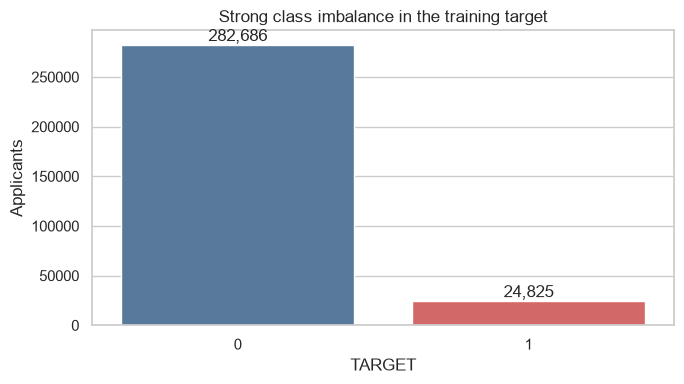

In [5]:
target_summary = pd.DataFrame(
    {
        "count": app_train[TARGET].value_counts().sort_index(),
        "share": app_train[TARGET].value_counts(normalize=True).sort_index(),
    }
).rename(index={0: "No payment difficulty", 1: "Payment difficulty"})
display(target_summary.style.format({"share": "{:.2%}"}))

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=app_train, x=TARGET, palette=["#4C78A8", "#E45756"], ax=ax)
ax.set(title="Strong class imbalance in the training target", xlabel="TARGET", ylabel="Applicants")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}")
plt.tight_layout()
plt.show()

## 3. Data types, cardinality, and missingness

In [6]:
numeric_cols = app_train.select_dtypes(include="number").columns.tolist()
categorical_cols = app_train.select_dtypes(exclude="number").columns.tolist()

type_summary = pd.DataFrame(
    {
        "columns": app_train.dtypes.astype(str).value_counts(),
    }
)
display(type_summary)

categorical_summary = pd.DataFrame(
    {
        "dtype": app_train[categorical_cols].dtypes.astype(str),
        "unique_including_missing": app_train[categorical_cols].nunique(dropna=False),
        "missing_pct": app_train[categorical_cols].isna().mean() * 100,
    }
).sort_values(["unique_including_missing", "missing_pct"], ascending=False)
display(categorical_summary)

,columns
float64,65
int64,41
object,16


,dtype,unique_including_missing,missing_pct
ORGANIZATION_TYPE,object,58,0.000
OCCUPATION_TYPE,object,19,31.346
WALLSMATERIAL_MODE,object,8,50.841
NAME_TYPE_SUITE,object,8,0.420
NAME_INCOME_TYPE,object,8,0.000
WEEKDAY_APPR_PROCESS_START,object,7,0.000
NAME_FAMILY_STATUS,object,6,0.000
NAME_HOUSING_TYPE,object,6,0.000
FONDKAPREMONT_MODE,object,5,68.386
NAME_EDUCATION_TYPE,object,5,0.000


,missing_count,missing_pct,dtype,unique
COMMONAREA_MEDI,214865,69.9%,float64,3202
COMMONAREA_AVG,214865,69.9%,float64,3181
COMMONAREA_MODE,214865,69.9%,float64,3128
NONLIVINGAPARTMENTS_MODE,213514,69.4%,float64,167
NONLIVINGAPARTMENTS_AVG,213514,69.4%,float64,386
NONLIVINGAPARTMENTS_MEDI,213514,69.4%,float64,214
FONDKAPREMONT_MODE,210295,68.4%,object,4
LIVINGAPARTMENTS_MODE,210199,68.4%,float64,736
LIVINGAPARTMENTS_AVG,210199,68.4%,float64,1868
LIVINGAPARTMENTS_MEDI,210199,68.4%,float64,1097


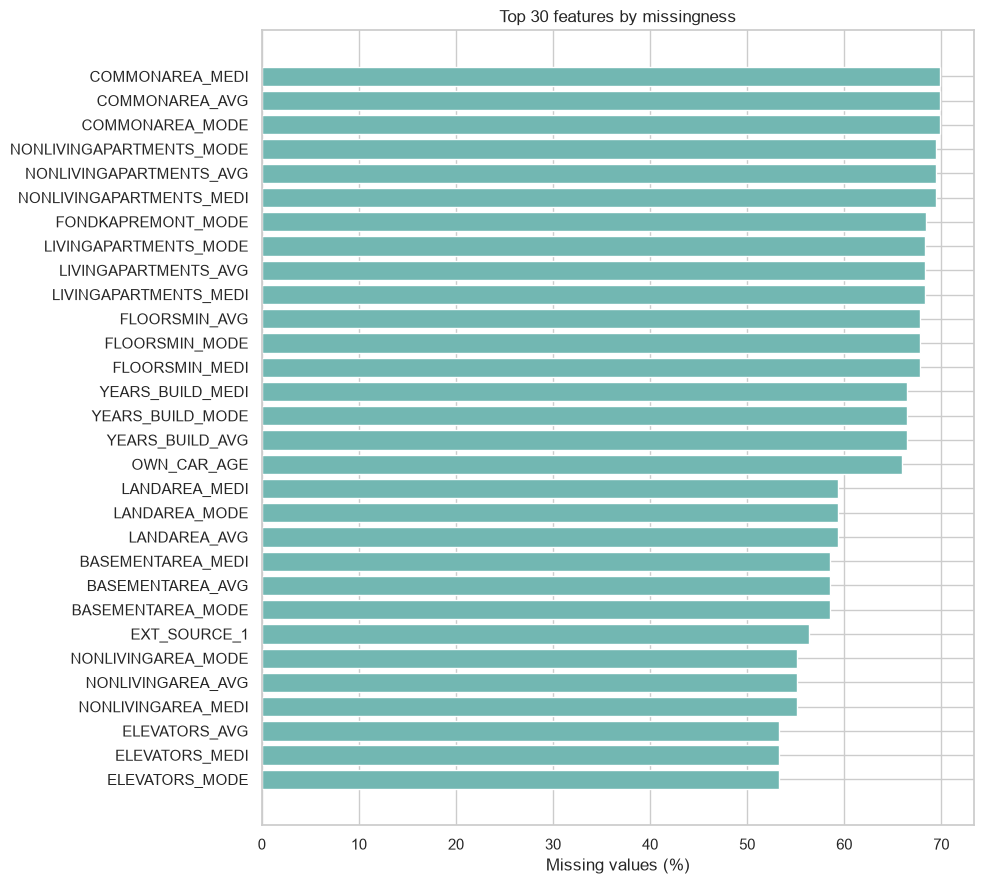

In [7]:
missingness = pd.DataFrame(
    {
        "missing_count": app_train.isna().sum(),
        "missing_pct": app_train.isna().mean() * 100,
        "dtype": app_train.dtypes.astype(str),
        "unique": app_train.nunique(dropna=True),
    }
).sort_values("missing_pct", ascending=False)

display(missingness.head(30).style.format({"missing_pct": "{:.1f}%"}))

plot_missing = missingness.query("missing_pct > 0").head(30).sort_values("missing_pct")
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(plot_missing.index, plot_missing["missing_pct"], color="#72B7B2")
ax.set(title="Top 30 features by missingness", xlabel="Missing values (%)", ylabel="")
plt.tight_layout()
plt.show()

In [8]:
missing_by_target = app_train.groupby(TARGET).apply(lambda frame: frame.isna().mean()).T
missing_by_target.columns = ["non_default_missing_pct", "default_missing_pct"]
missing_by_target *= 100
missing_by_target["absolute_gap_pp"] = (
    missing_by_target["default_missing_pct"] - missing_by_target["non_default_missing_pct"]
).abs()
display(missing_by_target.sort_values("absolute_gap_pp", ascending=False).head(20))

,non_default_missing_pct,default_missing_pct,absolute_gap_pp
EMERGENCYSTATE_MODE,46.786,54.373,7.587
TOTALAREA_MODE,47.659,55.210,7.552
ENTRANCES_MODE,49.743,57.245,7.502
ENTRANCES_AVG,49.743,57.245,7.502
ENTRANCES_MEDI,49.743,57.245,7.502
FLOORSMAX_AVG,49.156,56.653,7.497
FLOORSMAX_MEDI,49.156,56.653,7.497
FLOORSMAX_MODE,49.156,56.653,7.497
YEARS_BEGINEXPLUATATION_AVG,48.180,55.621,7.441
YEARS_BEGINEXPLUATATION_MEDI,48.180,55.621,7.441


## 4. Numeric ranges and known anomalies


In [9]:
numeric_summary = app_train[numeric_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
numeric_summary["missing_pct"] = app_train[numeric_cols].isna().mean() * 100
display(numeric_summary.sort_values("std", ascending=False).head(30))

quality_checks = pd.Series(
    {
        "DAYS_EMPLOYED == 365243": app_train["DAYS_EMPLOYED"].eq(365243).sum(),
        "DAYS_BIRTH >= 0": app_train["DAYS_BIRTH"].ge(0).sum(),
        "AMT_INCOME_TOTAL <= 0": app_train["AMT_INCOME_TOTAL"].le(0).sum(),
        "AMT_CREDIT <= 0": app_train["AMT_CREDIT"].le(0).sum(),
        "AMT_ANNUITY <= 0": app_train["AMT_ANNUITY"].le(0).sum(),
        "CODE_GENDER == XNA": app_train["CODE_GENDER"].eq("XNA").sum(),
        "OBS_30_CNT_SOCIAL_CIRCLE > 30": app_train["OBS_30_CNT_SOCIAL_CIRCLE"].gt(30).sum(),
    },
    name="rows",
)
display(quality_checks.to_frame())

employment_sentinel = app_train["DAYS_EMPLOYED"].eq(365243)
organization_xna = app_train["ORGANIZATION_TYPE"].eq("XNA")
employment_alignment = pd.crosstab(
    employment_sentinel.rename("employment_sentinel"),
    organization_xna.rename("organization_xna"),
    margins=True,
)
display(employment_alignment)
assert employment_sentinel.equals(organization_xna)

employment_signal = (
    app_train.assign(DAYS_EMPLOYED_ANOMALY=employment_sentinel)
    .groupby("DAYS_EMPLOYED_ANOMALY")[TARGET]
    .agg(applicants="size", defaults="sum", default_rate="mean")
)
display(employment_signal.style.format({"default_rate": "{:.2%}"}))

income_outliers = app_train.nlargest(5, "AMT_INCOME_TOTAL")[[
    ID_COL,
    TARGET,
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "NAME_CONTRACT_TYPE",
]]
social_circle_outliers = app_train.loc[
    app_train["OBS_30_CNT_SOCIAL_CIRCLE"].gt(30),
    [ID_COL, TARGET, "OBS_30_CNT_SOCIAL_CIRCLE"],
]
display(income_outliers)
display(social_circle_outliers)

,count,mean,std,min,1%,5%,50%,95%,99%,max,missing_pct
AMT_CREDIT,"307,511.000","599,026.000","402,490.777","45,000.000","76,410.000","135,000.000","513,531.000","1,350,000.000","1,854,000.000","4,050,000.000",0.000
AMT_GOODS_PRICE,"307,233.000","538,396.207","369,446.461","40,500.000","67,500.000","135,000.000","450,000.000","1,305,000.000","1,800,000.000","4,050,000.000",0.090
AMT_INCOME_TOTAL,"307,511.000","168,797.919","237,123.146","25,650.000","45,000.000","67,500.000","147,150.000","337,500.000","472,500.000","117,000,000.000",0.000
DAYS_EMPLOYED,"307,511.000","63,815.046","141,275.767","-17,912.000","-10,894.900","-6,742.500","-1,213.000","365,243.000","365,243.000","365,243.000",0.000
SK_ID_CURR,"307,511.000","278,180.519","102,790.175","100,002.000","103,590.200","117,945.500","278,202.000","438,427.500","452,712.900","456,255.000",0.000
AMT_ANNUITY,"307,499.000","27,108.574","14,493.737","1,615.500","6,182.910","9,000.000","24,903.000","53,325.000","70,006.500","258,025.500",0.004
DAYS_BIRTH,"307,511.000","-16,036.995","4,363.989","-25,229.000","-24,419.000","-23,204.000","-15,750.000","-9,407.000","-8,263.000","-7,489.000",0.000
DAYS_REGISTRATION,"307,511.000","-4,986.120","3,522.886","-24,672.000","-13,879.000","-11,416.000","-4,504.000",-330.000,-50.000,0.000,0.000
DAYS_ID_PUBLISH,"307,511.000","-2,994.202","1,509.450","-7,197.000","-5,447.000","-4,944.000","-3,254.000",-375.000,-61.000,0.000,0.000
DAYS_LAST_PHONE_CHANGE,"307,510.000",-962.859,826.808,"-4,292.000","-3,149.000","-2,522.000",-757.000,0.000,0.000,0.000,0.000


,rows
DAYS_EMPLOYED == 365243,55374
DAYS_BIRTH >= 0,0
AMT_INCOME_TOTAL <= 0,0
AMT_CREDIT <= 0,0
AMT_ANNUITY <= 0,0
CODE_GENDER == XNA,4
OBS_30_CNT_SOCIAL_CIRCLE > 30,2


organization_xna,False,True,All
employment_sentinel,,,
False,252137,0,252137
True,0,55374,55374
All,252137,55374,307511


,applicants,defaults,default_rate
DAYS_EMPLOYED_ANOMALY,,,
False,252137,21835,8.66%
True,55374,2990,5.40%


,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_CONTRACT_TYPE
12840,114967,1,"117,000,000.000","562,491.000","26,194.500",Cash loans
203693,336147,0,"18,000,090.000","675,000.000","69,295.500",Cash loans
246858,385674,0,"13,500,000.000","1,400,503.500","130,945.500",Cash loans
77768,190160,0,"9,000,000.000","1,431,531.000","132,601.500",Cash loans
131127,252084,0,"6,750,000.000","790,830.000","52,978.500",Cash loans


,SK_ID_CURR,TARGET,OBS_30_CNT_SOCIAL_CIRCLE
77497,189856,0,47.000
148403,272071,0,348.000


Days employed anamoly: False -> defaults: 8.66 percent || True -> defaults: 5.40 percent
meaning that the days empolyed (365243) those values are not defaulters giving wrong information. it is arising from somewhere else. Maybe the Null values were assigned an impossible value out of distribution.


In [10]:
eda = app_train.copy()
eda["DAYS_EMPLOYED_ANOMALY"] = employment_sentinel.astype("int8")
eda["DAYS_EMPLOYED_CLEAN"] = eda["DAYS_EMPLOYED"].replace(365243, np.nan)
eda["AGE_YEARS"] = -eda["DAYS_BIRTH"] / 365.25
eda["EMPLOYED_YEARS"] = -eda["DAYS_EMPLOYED_CLEAN"] / 365.25
eda["INCOME_CREDIT_RATIO"] = eda["AMT_INCOME_TOTAL"] / eda["AMT_CREDIT"].replace(0, np.nan)
eda["ANNUITY_CREDIT_RATIO"] = eda["AMT_ANNUITY"] / eda["AMT_CREDIT"].replace(0, np.nan)
eda["CREDIT_GOODS_RATIO"] = eda["AMT_CREDIT"] / eda["AMT_GOODS_PRICE"].replace(0, np.nan)
eda["INCOME_PER_PERSON"] = eda["AMT_INCOME_TOTAL"] / eda["CNT_FAM_MEMBERS"].replace(0, np.nan)
EXT_SOURCE_COLS = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
eda["EXT_SOURCE_MEAN"] = eda[EXT_SOURCE_COLS].mean(axis=1)
eda["EXT_SOURCE_COUNT"] = eda[EXT_SOURCE_COLS].notna().sum(axis=1).astype("int8")
eda["EXT_SOURCE_MISSING_COUNT"] = (len(EXT_SOURCE_COLS) - eda["EXT_SOURCE_COUNT"]).astype("int8")

derived_summary = eda[
    [
        "AGE_YEARS",
        "EMPLOYED_YEARS",
        "INCOME_CREDIT_RATIO",
        "ANNUITY_CREDIT_RATIO",
        "CREDIT_GOODS_RATIO",
        "INCOME_PER_PERSON",
        "EXT_SOURCE_MEAN",
        "EXT_SOURCE_COUNT",
        "EXT_SOURCE_MISSING_COUNT",
        "DAYS_EMPLOYED_ANOMALY",
    ]
].describe(percentiles=[0.01, 0.5, 0.99]).T
display(derived_summary)

,count,mean,std,min,1%,50%,99%,max
AGE_YEARS,"307,511.000",43.907,11.948,20.504,22.623,43.121,66.856,69.073
EMPLOYED_YEARS,"252,137.000",6.527,6.402,-0.000,0.304,4.512,31.043,49.040
INCOME_CREDIT_RATIO,"307,511.000",0.400,0.508,0.012,0.077,0.306,1.680,208.003
ANNUITY_CREDIT_RATIO,"307,499.000",0.054,0.022,0.022,0.026,0.050,0.115,0.124
CREDIT_GOODS_RATIO,"307,233.000",1.123,0.124,0.150,1.000,1.119,1.475,6.000
INCOME_PER_PERSON,"307,509.000","93,105.880","101,373.363","2,812.500","18,000.000","75,000.000","337,500.000","39,000,000.000"
EXT_SOURCE_MEAN,"307,339.000",0.509,0.150,0.000,0.110,0.525,0.773,0.879
EXT_SOURCE_COUNT,"307,511.000",2.236,0.650,0.000,1.000,2.000,3.000,3.000
EXT_SOURCE_MISSING_COUNT,"307,511.000",0.764,0.650,0.000,0.000,1.000,2.000,3.000
DAYS_EMPLOYED_ANOMALY,"307,511.000",0.180,0.384,0.000,0.000,0.000,1.000,1.000


## 5. Numeric distributions by target


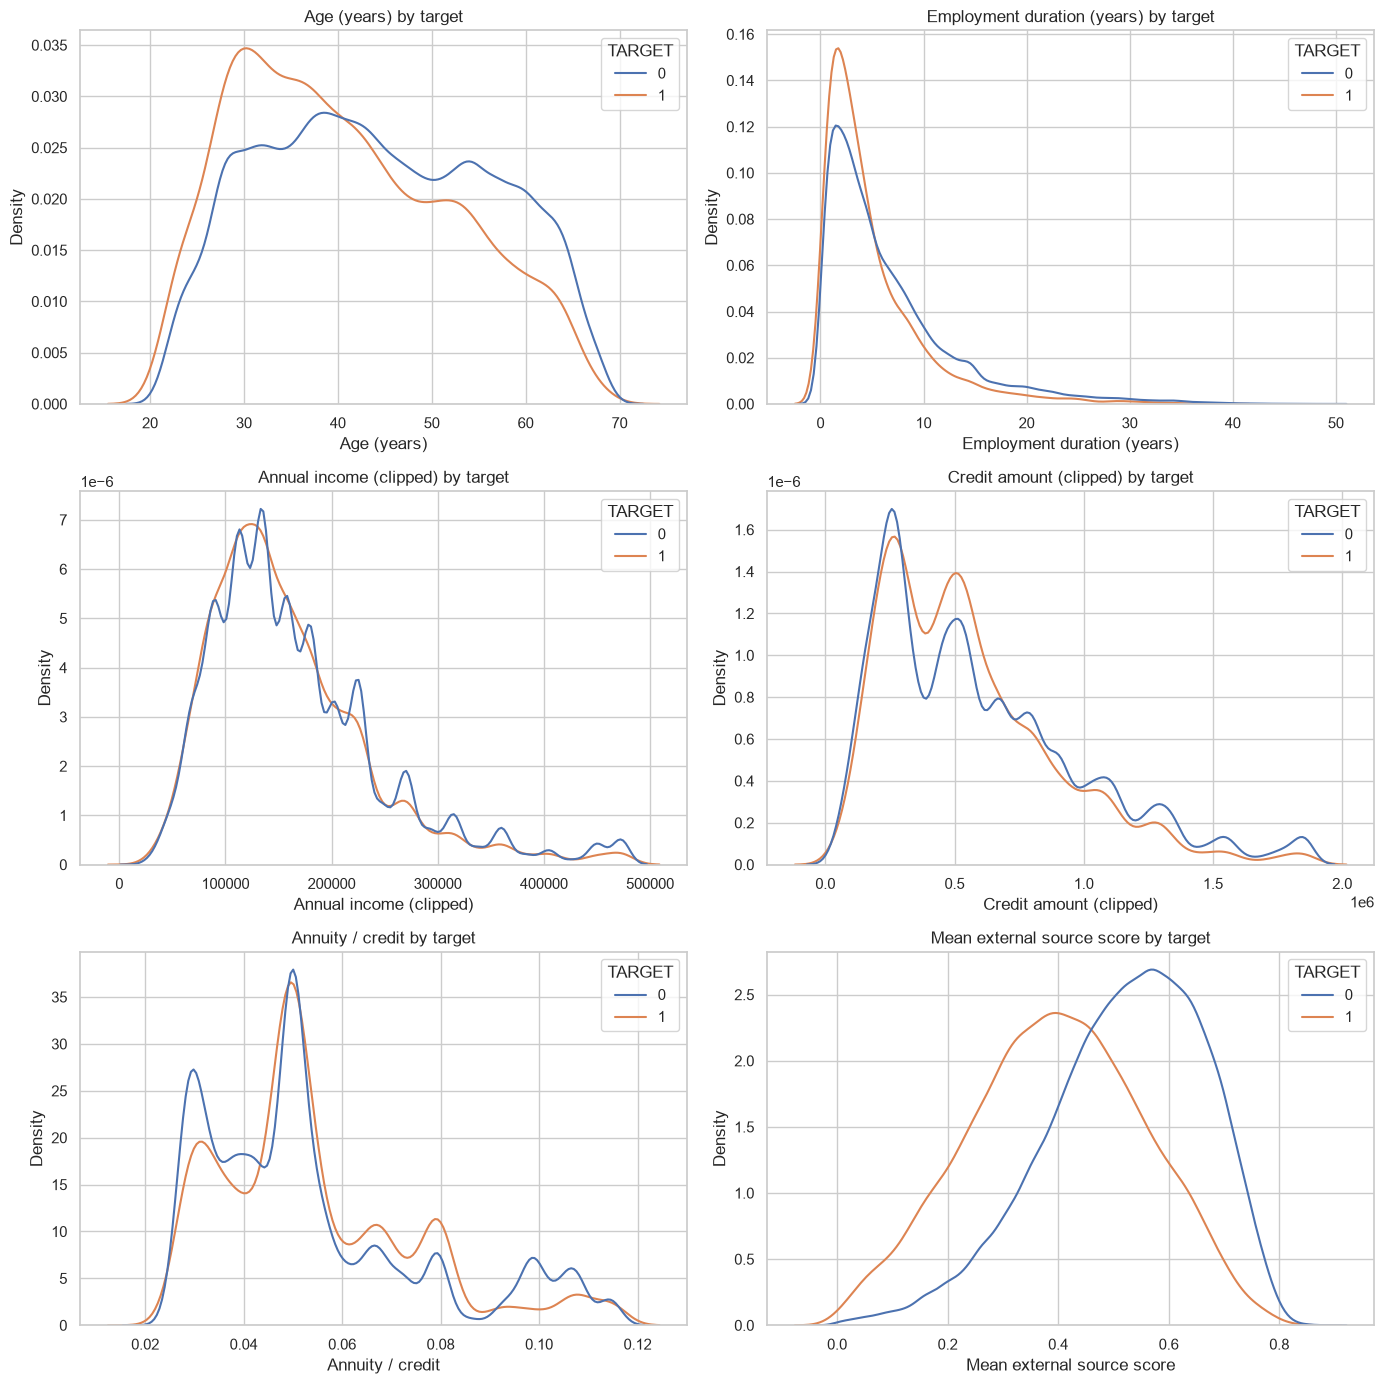

In [11]:
plot_specs = [
    ("AGE_YEARS", "Age (years)", None),
    ("EMPLOYED_YEARS", "Employment duration (years)", None),
    ("AMT_INCOME_TOTAL", "Annual income (clipped)", 0.99),
    ("AMT_CREDIT", "Credit amount (clipped)", 0.99),
    ("ANNUITY_CREDIT_RATIO", "Annuity / credit", 0.99),
    ("EXT_SOURCE_MEAN", "Mean external source score", None),
]

sample = eda.sample(min(120_000, len(eda)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for ax, (column, label, clip_quantile) in zip(axes.flat, plot_specs):
    frame = sample[[column, TARGET]].dropna().copy()
    if clip_quantile is not None:
        frame[column] = frame[column].clip(upper=eda[column].quantile(clip_quantile))
    sns.kdeplot(data=frame, x=column, hue=TARGET, common_norm=False, fill=False, ax=ax)
    ax.set(title=f"{label} by target", xlabel=label)
plt.tight_layout()
plt.show()

In [12]:
def quantile_default_table(frame: pd.DataFrame, column: str, bins: int = 10) -> pd.DataFrame:
    valid = frame[[column, TARGET]].dropna().copy()
    valid["bin"] = pd.qcut(valid[column], q=bins, duplicates="drop")
    result = valid.groupby("bin", observed=True).agg(
        applicants=(TARGET, "size"),
        defaults=(TARGET, "sum"),
        default_rate=(TARGET, "mean"),
        feature_median=(column, "median"),
    )
    return result.reset_index()


for column in ["EXT_SOURCE_MEAN", "ANNUITY_CREDIT_RATIO", "CREDIT_GOODS_RATIO", "INCOME_CREDIT_RATIO", "AGE_YEARS"]:
    table = quantile_default_table(eda, column)
    display(table.style.format({"default_rate": "{:.2%}", "feature_median": "{:,.3f}"}))

,bin,applicants,defaults,default_rate,feature_median
0,"(-0.00099406, 0.304]",30734,7048,22.93%,0.235
1,"(0.304, 0.384]",30734,4461,14.51%,0.349
2,"(0.384, 0.439]",30734,3228,10.50%,0.414
3,"(0.439, 0.484]",30734,2494,8.11%,0.462
4,"(0.484, 0.525]",30734,1975,6.43%,0.505
5,"(0.525, 0.564]",30733,1656,5.39%,0.544
6,"(0.564, 0.603]",30736,1277,4.15%,0.583
7,"(0.603, 0.644]",30732,1148,3.74%,0.623
8,"(0.644, 0.693]",30734,897,2.92%,0.667
9,"(0.693, 0.879]",30734,627,2.04%,0.725


,bin,applicants,defaults,default_rate,feature_median
0,"(0.0211, 0.0294]",31073,1836,5.91%,0.029
1,"(0.0294, 0.0332]",30463,2158,7.08%,0.032
2,"(0.0332, 0.0397]",31107,2265,7.28%,0.037
3,"(0.0397, 0.0454]",30361,1533,5.05%,0.042
4,"(0.0454, 0.05]",56626,5513,9.74%,0.050
5,"(0.05, 0.0512]",5133,466,9.08%,0.051
6,"(0.0512, 0.0563]",30493,3012,9.88%,0.053
7,"(0.0563, 0.0684]",30745,3077,10.01%,0.064
8,"(0.0684, 0.0951]",30758,3478,11.31%,0.079
9,"(0.0951, 0.124]",30740,1487,4.84%,0.105


,bin,applicants,defaults,default_rate,feature_median
0,"(0.149, 1.0]",108470,7318,6.75%,1.000
1,"(1.0, 1.079]",14508,689,4.75%,1.066
2,"(1.079, 1.119]",37511,2542,6.78%,1.106
3,"(1.119, 1.145]",28442,1918,6.74%,1.132
4,"(1.145, 1.168]",26132,2302,8.81%,1.158
5,"(1.168, 1.211]",37921,3810,10.05%,1.198
6,"(1.211, 1.277]",24266,2405,9.91%,1.238
7,"(1.277, 6.0]",29983,3820,12.74%,1.396


,bin,applicants,defaults,default_rate,feature_median
0,"(0.0108, 0.134]",30790,2177,7.07%,0.109
1,"(0.134, 0.173]",30784,2285,7.42%,0.154
2,"(0.173, 0.212]",30685,2444,7.96%,0.194
3,"(0.212, 0.256]",30783,2655,8.62%,0.234
4,"(0.256, 0.306]",30724,2825,9.19%,0.281
5,"(0.306, 0.362]",30992,2694,8.69%,0.333
6,"(0.362, 0.441]",30502,2738,8.98%,0.400
7,"(0.441, 0.55]",31022,2524,8.14%,0.496
8,"(0.55, 0.751]",30484,2358,7.74%,0.633
9,"(0.751, 208.003]",30745,2125,6.91%,1.000


,bin,applicants,defaults,default_rate,feature_median
0,"(20.503, 28.156]",30752,3558,11.57%,25.755
1,"(28.156, 32.016]",30760,3382,10.99%,30.130
2,"(32.016, 35.975]",30745,3015,9.81%,33.988
3,"(35.975, 39.469]",30759,2723,8.85%,37.741
4,"(39.469, 43.121]",30745,2430,7.90%,41.262
5,"(43.121, 47.146]",30764,2398,7.79%,45.070
6,"(47.146, 51.704]",30733,2193,7.14%,49.383
7,"(51.704, 56.055]",30758,1951,6.34%,53.886
8,"(56.055, 60.728]",30757,1668,5.42%,58.360
9,"(60.728, 69.073]",30738,1507,4.90%,63.529


In [13]:
eda["ANNUITY_CREDIT_BIN"] = pd.qcut(
    eda["ANNUITY_CREDIT_RATIO"], q=10, duplicates="drop"
)
annuity_ratio_profile = eda.groupby("ANNUITY_CREDIT_BIN", observed=True).agg(
    applicants=(TARGET, "size"),
    default_rate=(TARGET, "mean"),
    ratio_median=("ANNUITY_CREDIT_RATIO", "median"),
    income_median=("AMT_INCOME_TOTAL", "median"),
    credit_median=("AMT_CREDIT", "median"),
    credit_goods_ratio_median=("CREDIT_GOODS_RATIO", "median"),
)
annuity_contract_mix = pd.crosstab(
    eda["ANNUITY_CREDIT_BIN"],
    eda["NAME_CONTRACT_TYPE"],
    normalize="index",
).mul(100)

high_ratio_bin = eda["ANNUITY_CREDIT_BIN"].cat.categories[-1]
high_ratio_mask = eda["ANNUITY_CREDIT_BIN"].eq(high_ratio_bin)
high_ratio_profile = eda.assign(high_ratio_bin=high_ratio_mask).groupby("high_ratio_bin").agg(
    applicants=(TARGET, "size"),
    default_rate=(TARGET, "mean"),
    income_median=("AMT_INCOME_TOTAL", "median"),
    credit_median=("AMT_CREDIT", "median"),
    goods_price_median=("AMT_GOODS_PRICE", "median"),
    credit_goods_ratio_median=("CREDIT_GOODS_RATIO", "median"),
)
annuity_exact_005 = np.isclose(
    eda["ANNUITY_CREDIT_RATIO"], 0.05, rtol=0, atol=1e-12
).sum()

display(annuity_ratio_profile.style.format({"default_rate": "{:.2%}"}))
display(annuity_contract_mix.style.format("{:.1f}%"))
display(high_ratio_profile.style.format({"default_rate": "{:.2%}"}))

,applicants,default_rate,ratio_median,income_median,credit_median,credit_goods_ratio_median
ANNUITY_CREDIT_BIN,,,,,,
"(0.0211, 0.0294]",31073,5.91%,0.029231,180000.000000,1183963.500000,1.145200
"(0.0294, 0.0332]",30463,7.08%,0.032257,148500.000000,810000.000000,1.198000
"(0.0332, 0.0397]",31107,7.28%,0.036932,157500.000000,679500.000000,1.158400
"(0.0397, 0.0454]",30361,5.05%,0.042498,157500.000000,755190.000000,1.118800
"(0.0454, 0.05]",56626,9.74%,0.050000,135000.000000,358443.000000,1.000000
"(0.05, 0.0512]",5133,9.08%,0.051059,180000.000000,675000.000000,1.118800
"(0.0512, 0.0563]",30493,9.88%,0.053403,157500.000000,501363.000000,1.158397
"(0.0563, 0.0684]",30745,10.01%,0.064045,135000.000000,314100.000000,1.132000
"(0.0684, 0.0951]",30758,11.31%,0.079007,139500.000000,286704.000000,1.105600


NAME_CONTRACT_TYPE,Cash loans,Revolving loans
ANNUITY_CREDIT_BIN,,
"(0.0211, 0.0294]",100.0%,0.0%
"(0.0294, 0.0332]",100.0%,0.0%
"(0.0332, 0.0397]",100.0%,0.0%
"(0.0397, 0.0454]",100.0%,0.0%
"(0.0454, 0.05]",48.4%,51.6%
"(0.05, 0.0512]",100.0%,0.0%
"(0.0512, 0.0563]",100.0%,0.0%
"(0.0563, 0.0684]",100.0%,0.0%
"(0.0684, 0.0951]",100.0%,0.0%


,applicants,default_rate,income_median,credit_median,goods_price_median,credit_goods_ratio_median
high_ratio_bin,,,,,,
False,276771,8.43%,153000.000000,545040.000000,454500.000000,1.118800
True,30740,4.84%,135000.000000,225000.000000,225000.000000,1.066000


## 6. Categorical segments and default rates


In [14]:
def category_default_table(
    frame: pd.DataFrame, column: str, min_count: int = 500
) -> pd.DataFrame:
    values = frame[column].astype("string").fillna("<MISSING>")
    table = (
        frame.assign(_category=values)
        .groupby("_category", observed=True)[TARGET]
        .agg(applicants="size", defaults="sum", default_rate="mean")
        .query("applicants >= @min_count")
        .sort_values("default_rate", ascending=False)
    )
    table.index.name = column
    return table


categorical_features = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
]

for column in categorical_features:
    table = category_default_table(eda, column)
    display(table.style.format({"default_rate": "{:.2%}"}))

,applicants,defaults,default_rate
NAME_CONTRACT_TYPE,,,
Cash loans,278232,23221,8.35%
Revolving loans,29279,1604,5.48%


,applicants,defaults,default_rate
CODE_GENDER,,,
M,105059,10655,10.14%
F,202448,14170,7.00%


,applicants,defaults,default_rate
FLAG_OWN_CAR,,,
N,202924,17249,8.50%
Y,104587,7576,7.24%


,applicants,defaults,default_rate
FLAG_OWN_REALTY,,,
N,94199,7842,8.32%
Y,213312,16983,7.96%


,applicants,defaults,default_rate
NAME_INCOME_TYPE,,,
Working,158774,15224,9.59%
Commercial associate,71617,5360,7.48%
State servant,21703,1249,5.75%
Pensioner,55362,2982,5.39%


,applicants,defaults,default_rate
NAME_EDUCATION_TYPE,,,
Lower secondary,3816,417,10.93%
Secondary / secondary special,218391,19524,8.94%
Incomplete higher,10277,872,8.48%
Higher education,74863,4009,5.36%


,applicants,defaults,default_rate
NAME_FAMILY_STATUS,,,
Civil marriage,29775,2961,9.94%
Single / not married,45444,4457,9.81%
Separated,19770,1620,8.19%
Married,196432,14850,7.56%
Widow,16088,937,5.82%


,applicants,defaults,default_rate
NAME_HOUSING_TYPE,,,
Rented apartment,4881,601,12.31%
With parents,14840,1736,11.70%
Municipal apartment,11183,955,8.54%
Co-op apartment,1122,89,7.93%
House / apartment,272868,21272,7.80%
Office apartment,2617,172,6.57%


,applicants,defaults,default_rate
OCCUPATION_TYPE,,,
Low-skill Laborers,2093,359,17.15%
Drivers,18603,2107,11.33%
Waiters/barmen staff,1348,152,11.28%
Security staff,6721,722,10.74%
Laborers,55186,5838,10.58%
Cooking staff,5946,621,10.44%
Sales staff,32102,3092,9.63%
Cleaning staff,4653,447,9.61%
Realty agents,751,59,7.86%


,applicants,defaults,default_rate
ORGANIZATION_TYPE,,,
Transport: type 3,1187,187,15.75%
Restaurant,1811,212,11.71%
Construction,6721,785,11.68%
Industry: type 1,1039,115,11.07%
Industry: type 3,3278,348,10.62%
Agriculture,2454,257,10.47%
Trade: type 3,3492,361,10.34%
Self-employed,38412,3908,10.17%
Industry: type 4,877,89,10.15%


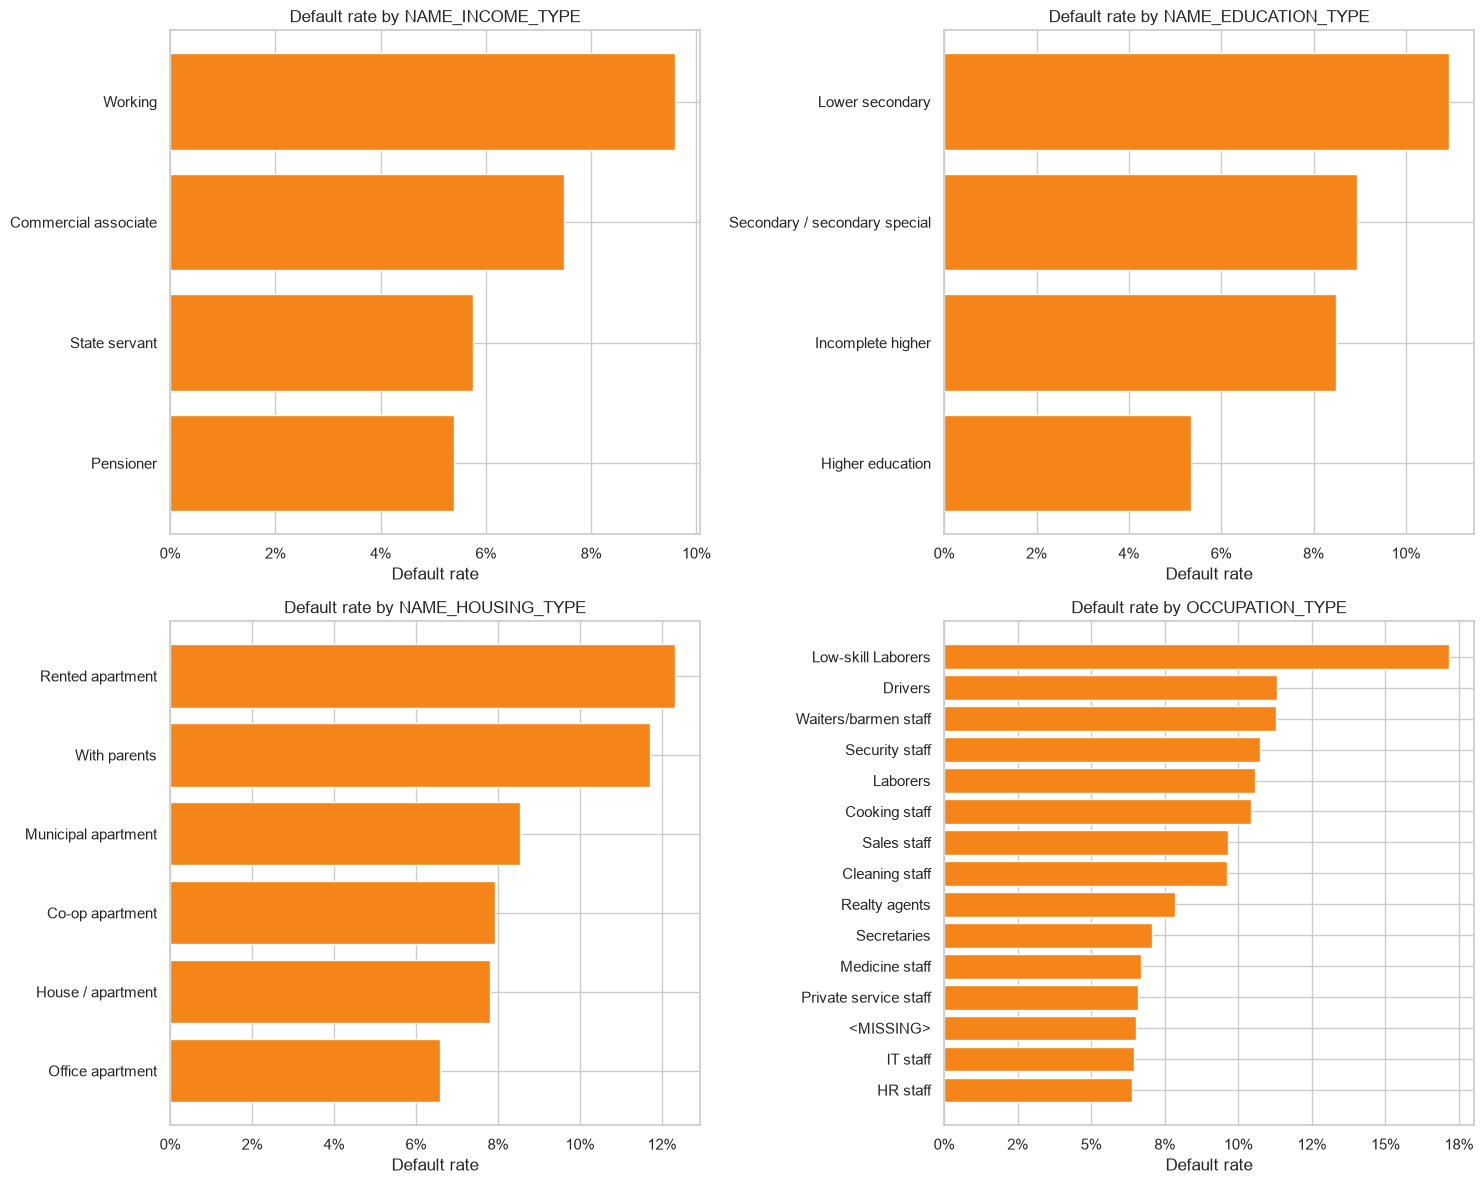

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for ax, column in zip(
    axes.flat,
    ["NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_HOUSING_TYPE", "OCCUPATION_TYPE"],
):
    table = category_default_table(eda, column).head(15).sort_values("default_rate")
    ax.barh(table.index, table["default_rate"], color="#F58518")
    ax.set(title=f"Default rate by {column}", xlabel="Default rate", ylabel="")
    ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()

## 7. External scores and numeric associations


EXT_SOURCE_1              EXT_SOURCE_2              EXT_SOURCE_3        \
              count  mean median        count  mean median        count  mean   
TARGET                                                                          
0            124079 0.511  0.517       282078 0.523  0.574       227398 0.521   
1             10054 0.387  0.362        24773 0.411  0.440        19148 0.391   

              EXT_SOURCE_MEAN               
       median           count  mean median  
TARGET                                      
0       0.546          282528 0.519  0.534  
1       0.379           24811 0.397  0.399

,applicants,defaults,default_rate
EXT_SOURCE_COUNT,,,
0,172,14,8.14%
1,36737,3645,9.92%
2,161013,13168,8.18%
3,109589,7998,7.30%


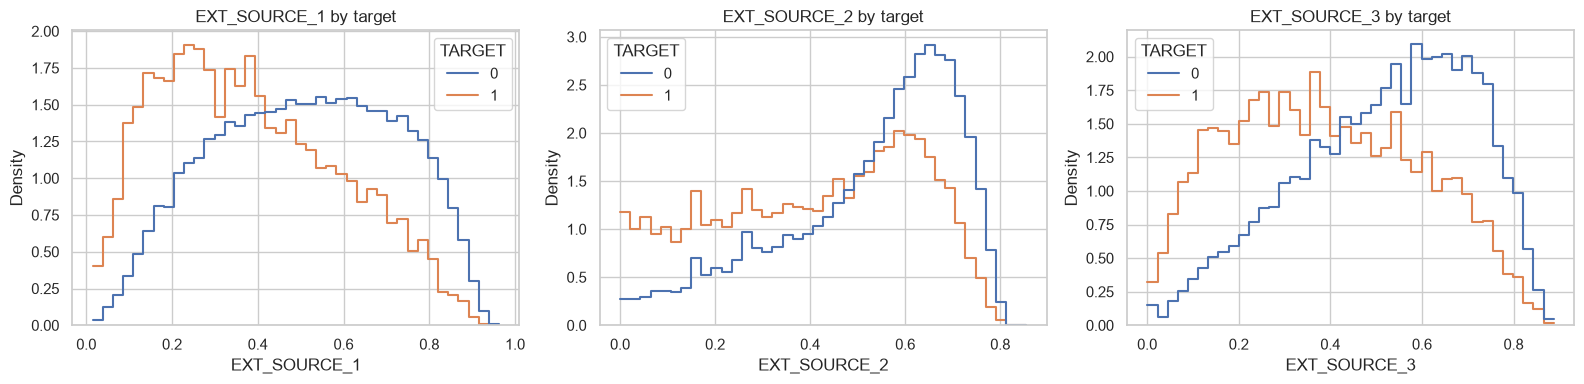

In [16]:
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "EXT_SOURCE_MEAN"]
ext_summary = eda.groupby(TARGET)[ext_cols].agg(["count", "mean", "median"])
display(ext_summary)

ext_availability = eda.groupby("EXT_SOURCE_COUNT", observed=True)[TARGET].agg(
    applicants="size", defaults="sum", default_rate="mean"
)
display(ext_availability.style.format({"default_rate": "{:.2%}"}))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, column in zip(axes, ext_cols[:3]):
    sns.histplot(
        data=sample,
        x=column,
        hue=TARGET,
        bins=40,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        ax=ax,
    )
    ax.set(title=f"{column} by target")
plt.tight_layout()
plt.show()

,pearson_correlation_with_target
EXT_SOURCE_MEAN,-0.222
EXT_SOURCE_3,-0.179
EXT_SOURCE_2,-0.160
EXT_SOURCE_1,-0.155
AGE_YEARS,-0.078
DAYS_BIRTH,0.078
DAYS_EMPLOYED_CLEAN,0.075
EMPLOYED_YEARS,-0.075
CREDIT_GOODS_RATIO,0.069
REGION_RATING_CLIENT_W_CITY,0.061


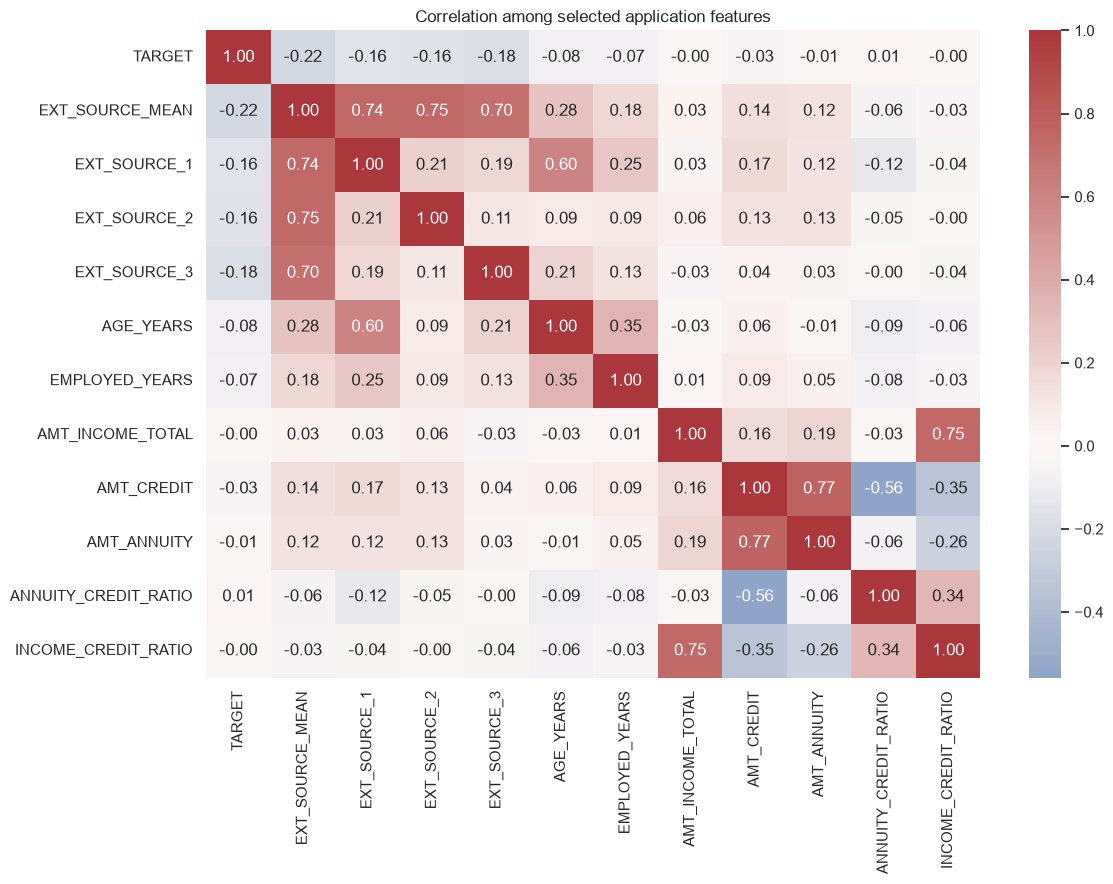

In [17]:
analysis_numeric_cols = [
    column
    for column in eda.select_dtypes(include="number").columns
    if column not in {TARGET, ID_COL} and not column.startswith("SK_ID_")
]
pearson_target_corr = (
    eda[analysis_numeric_cols + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
)
display(pearson_target_corr.head(25).rename("pearson_correlation_with_target").to_frame())

heatmap_cols = [
    TARGET,
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "AGE_YEARS",
    "EMPLOYED_YEARS",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "ANNUITY_CREDIT_RATIO",
    "INCOME_CREDIT_RATIO",
]
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(eda[heatmap_cols].corr(), cmap="vlag", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("Correlation among selected application features")
plt.tight_layout()
plt.show()

## 8. Train/test distribution shift


In [18]:
common_numeric = [column for column in app_test.select_dtypes(include="number") if column != ID_COL]
train_mean = app_train[common_numeric].mean()
test_mean = app_test[common_numeric].mean()
pooled_std = np.sqrt((app_train[common_numeric].var() + app_test[common_numeric].var()) / 2)

numeric_shift = pd.DataFrame(
    {
        "train_mean": train_mean,
        "test_mean": test_mean,
        "standardized_mean_diff": (test_mean - train_mean) / pooled_std.replace(0, np.nan),
        "train_missing_pct": app_train[common_numeric].isna().mean() * 100,
        "test_missing_pct": app_test[common_numeric].isna().mean() * 100,
    }
)
numeric_shift["missing_gap_pp"] = (
    numeric_shift["test_missing_pct"] - numeric_shift["train_missing_pct"]
)
display(
    numeric_shift.sort_values("standardized_mean_diff", key=np.abs, ascending=False).head(25)
)
print("Train/test shift is descriptive only because the competition test set is unlabeled.")

,train_mean,test_mean,standardized_mean_diff,train_missing_pct,test_missing_pct,missing_gap_pp
AMT_REQ_CREDIT_BUREAU_MON,0.267,0.009,-0.396,13.502,12.410,-1.092
AMT_REQ_CREDIT_BUREAU_QRT,0.265,0.547,0.378,13.502,12.410,-1.092
FLAG_EMAIL,0.057,0.163,0.344,0.000,0.000,0.000
AMT_GOODS_PRICE,"538,396.207","462,618.840",-0.214,0.090,0.000,-0.090
AMT_CREDIT,"599,026.000","516,740.436",-0.214,0.000,0.000,0.000
AMT_REQ_CREDIT_BUREAU_WEEK,0.034,0.003,-0.211,13.502,12.410,-1.092
FLAG_DOCUMENT_3,0.710,0.787,0.177,0.000,0.000,0.000
AMT_ANNUITY,"27,108.574","29,426.240",0.152,0.004,0.049,0.045
FLAG_DOCUMENT_16,0.010,0.000,-0.142,0.000,0.000,0.000
DAYS_LAST_PHONE_CHANGE,-962.859,"-1,077.766",-0.135,0.000,0.000,-0.000


Train/test shift is descriptive only because the competition test set is unlabeled.


In [19]:
def categorical_shift(frame_a: pd.DataFrame, frame_b: pd.DataFrame, column: str) -> float:
    dist_a = frame_a[column].astype("string").fillna("<MISSING>").value_counts(normalize=True)
    dist_b = frame_b[column].astype("string").fillna("<MISSING>").value_counts(normalize=True)
    aligned = pd.concat([dist_a, dist_b], axis=1).fillna(0)
    return 0.5 * (aligned.iloc[:, 0] - aligned.iloc[:, 1]).abs().sum()


categorical_shift_summary = pd.Series(
    {
        column: categorical_shift(app_train, app_test, column)
        for column in categorical_cols
    },
    name="total_variation_distance",
).sort_values(ascending=False)
display(categorical_shift_summary.head(20).to_frame())

,total_variation_distance
NAME_CONTRACT_TYPE,0.086
WEEKDAY_APPR_PROCESS_START,0.045
ORGANIZATION_TYPE,0.026
NAME_FAMILY_STATUS,0.024
NAME_TYPE_SUITE,0.021
WALLSMATERIAL_MODE,0.020
EMERGENCYSTATE_MODE,0.019
HOUSETYPE_MODE,0.017
NAME_EDUCATION_TYPE,0.016
OCCUPATION_TYPE,0.015


## 9. Relational history setup and temporal safety

### QUESTION
What does one row mean in each historical table, and are the time fields historical at the current application date?

### ACTION
Use `SK_ID_CURR` as the applicant key, retain `SK_ID_BUREAU` only for the bureau-balance hierarchy, and inspect each time range during the same restricted read used for analysis. Recency fields must be non-positive; no future-looking values are clipped to force an assertion to pass.

In [20]:
def safe_divide(numerator, denominator, positive_denominator=False):
    valid = denominator.gt(0) if positive_denominator else denominator.ne(0)
    return (numerator / denominator.where(valid)).replace([np.inf, -np.inf], np.nan)


TIME_RANGES = {}


def record_time_range(table, column, values):
    valid = values.dropna()
    current = {
        "table": table, "column": column, "min": float(valid.min()), "max": float(valid.max()),
        "missing": int(values.isna().sum()), "positive": int(values.gt(0).sum()),
    }
    key = (table, column)
    if key in TIME_RANGES:
        prior = TIME_RANGES[key]
        current["min"] = min(prior["min"], current["min"])
        current["max"] = max(prior["max"], current["max"])
        current["missing"] += prior["missing"]
        current["positive"] += prior["positive"]
    TIME_RANGES[key] = current
    assert current["positive"] == 0, f"Unexpected future-looking values in {table}.{column}"


def combine_state(state, name, values, operation="sum"):
    if name not in state:
        state[name] = values
    elif operation == "sum":
        state[name] = state[name].add(values, fill_value=0)
    elif operation == "max":
        state[name] = pd.concat([state[name], values], axis=1).max(axis=1)
    else:
        raise ValueError(operation)


def history_presence_table(frame, history_column):
    state = frame[history_column].eq(1).map({False: "NO_HISTORY", True: "HAS_HISTORY"})
    return frame.assign(_state=state).groupby("_state")[TARGET].agg(applicants="size", default_rate="mean")


def history_signal_table(frame, history_column, signal):
    has_history = frame[history_column].eq(1)
    state = pd.Series("NO_HISTORY", index=frame.index, dtype="object")
    state.loc[has_history & ~signal.eq(True)] = "HISTORY_SIGNAL_ABSENT"
    state.loc[has_history & signal.eq(True)] = "HISTORY_SIGNAL_PRESENT"
    return frame.assign(_state=state).groupby("_state")[TARGET].agg(applicants="size", default_rate="mean")


def show_finding(text, implication):
    display(Markdown(f"### FINDING\n{text}\n\n### IMPLICATION\n{implication}"))


target_base = app_train[[ID_COL, TARGET]].copy()

## 10. Bureau

### QUESTION
How many loans does an applicant have, what share is active or closed, how large are credit/debt/overdue amounts, how recent is the history, and is microloan count more informative than simple presence?

### ACTION
Inspect raw status/type frequencies, then create a small temporary applicant aggregate containing counts, shares, selected amounts, debt/credit, and `DAYS_CREDIT` summaries.

In [21]:
bureau = pd.read_csv(DATA_DIR / "bureau.csv", usecols=[
    ID_COL, "SK_ID_BUREAU", "CREDIT_ACTIVE", "CREDIT_TYPE", "AMT_CREDIT_SUM",
    "AMT_CREDIT_SUM_DEBT", "AMT_CREDIT_SUM_OVERDUE", "AMT_CREDIT_MAX_OVERDUE", "DAYS_CREDIT",
])
record_time_range("bureau", "DAYS_CREDIT", bureau["DAYS_CREDIT"])
assert bureau["SK_ID_BUREAU"].is_unique
display(bureau["CREDIT_ACTIVE"].value_counts(dropna=False).to_frame("loans"))
display(bureau["CREDIT_TYPE"].value_counts(dropna=False).to_frame("loans"))
bureau["ACTIVE"] = bureau["CREDIT_ACTIVE"].eq("Active").astype("int8")
bureau["CLOSED"] = bureau["CREDIT_ACTIVE"].eq("Closed").astype("int8")
bureau["MICROLOAN"] = bureau["CREDIT_TYPE"].eq("Microloan").astype("int8")
bg = bureau.groupby(ID_COL, sort=True)
bureau_eda = pd.DataFrame(index=bg.size().index)
bureau_eda["BUREAU_RECORD_COUNT"] = bg.size()
bureau_eda["HAS_BUREAU_HISTORY"] = 1
bureau_eda["BUREAU_ACTIVE_COUNT"] = bg["ACTIVE"].sum()
bureau_eda["BUREAU_CLOSED_COUNT"] = bg["CLOSED"].sum()
bureau_eda["BUREAU_ACTIVE_SHARE"] = bg["ACTIVE"].mean()
bureau_eda["BUREAU_CLOSED_SHARE"] = bg["CLOSED"].mean()
bureau_eda["BUREAU_CREDIT_SUM"] = bg["AMT_CREDIT_SUM"].sum(min_count=1)
bureau_eda["BUREAU_DEBT_SUM"] = bg["AMT_CREDIT_SUM_DEBT"].sum(min_count=1)
bureau_eda["BUREAU_OVERDUE_SUM"] = bg["AMT_CREDIT_SUM_OVERDUE"].sum(min_count=1)
bureau_eda["BUREAU_MAX_OVERDUE"] = bg["AMT_CREDIT_MAX_OVERDUE"].max()
bureau_eda["BUREAU_DEBT_CREDIT_RATIO"] = safe_divide(bureau_eda["BUREAU_DEBT_SUM"], bureau_eda["BUREAU_CREDIT_SUM"])
bureau_eda["BUREAU_DAYS_CREDIT_MEAN"] = bg["DAYS_CREDIT"].mean()
bureau_eda["BUREAU_DAYS_CREDIT_MAX"] = bg["DAYS_CREDIT"].max()
bureau_eda["BUREAU_MICROLOAN_COUNT"] = bg["MICROLOAN"].sum()
bureau_eda["HAS_MICROLOAN"] = bureau_eda["BUREAU_MICROLOAN_COUNT"].gt(0).astype("int8")
bureau_keys = bureau[["SK_ID_BUREAU", ID_COL]].copy()
bureau_eval = target_base.merge(bureau_eda, left_on=ID_COL, right_index=True, how="left", validate="one_to_one")
bureau_eval["HAS_BUREAU_HISTORY"] = bureau_eval["HAS_BUREAU_HISTORY"].fillna(0).astype("int8")
display(history_presence_table(bureau_eval, "HAS_BUREAU_HISTORY").style.format({"default_rate": "{:.2%}"}))
bureau_active_states = history_signal_table(bureau_eval, "HAS_BUREAU_HISTORY", bureau_eval["BUREAU_ACTIVE_COUNT"].gt(0))
display(bureau_active_states.style.format({"default_rate": "{:.2%}"}))
for column in ["BUREAU_ACTIVE_SHARE", "BUREAU_DEBT_CREDIT_RATIO", "BUREAU_DAYS_CREDIT_MAX", "BUREAU_MICROLOAN_COUNT"]:
    display(Markdown(f"**{column}**"))
    display(quantile_default_table(bureau_eval[bureau_eval.HAS_BUREAU_HISTORY.eq(1)], column, bins=5).style.format({"default_rate": "{:.2%}"}))
active_absent_rate = bureau_active_states.loc["HISTORY_SIGNAL_ABSENT", "default_rate"]
active_present_rate = bureau_active_states.loc["HISTORY_SIGNAL_PRESENT", "default_rate"]
show_finding(
    f"Among applicants with bureau history, the observed default rate is {active_absent_rate:.2%} without an active loan and {active_present_rate:.2%} with one. The displayed bins show how active share, debt/credit, recency, and microloan count behave beyond binary presence.",
    "Build one compact bureau family with counts, shares, amount burdens, debt/credit, recency, and microloan count. Avoid type × status × time interactions.",
)
del bureau

,loans
CREDIT_ACTIVE,
Closed,1079273
Active,630607
Sold,6527
Bad debt,21


,loans
CREDIT_TYPE,
Consumer credit,1251615
Credit card,402195
Car loan,27690
Mortgage,18391
Microloan,12413
Loan for business development,1975
Another type of loan,1017
Unknown type of loan,555
Loan for working capital replenishment,469


,applicants,default_rate
_state,,
HAS_HISTORY,263491,7.73%
NO_HISTORY,44020,10.12%


,applicants,default_rate
_state,,
HISTORY_SIGNAL_ABSENT,46341,5.66%
HISTORY_SIGNAL_PRESENT,217150,8.17%
NO_HISTORY,44020,10.12%


**BUREAU_ACTIVE_SHARE**

...

**BUREAU_DAYS_CREDIT_MAX**

,bin,applicants,defaults,default_rate,feature_median
0,"(-2922.001, -742.0]",52765,2937,5.57%,-1169.000000
1,"(-742.0, -389.0]",52859,3189,6.03%,-521.000000
2,"(-389.0, -229.0]",52707,3800,7.21%,-300.000000
3,"(-229.0, -117.0]",52811,4667,8.84%,-170.000000
4,"(-117.0, 0.0]",52349,5775,11.03%,-66.000000


**BUREAU_MICROLOAN_COUNT**

,bin,applicants,defaults,default_rate,feature_median
0,"(-0.001, 79.0]",263491,20368,7.73%,0.000000


### FINDING
Among applicants with bureau history, the observed default rate is 5.66% without an active loan and 8.17% with one. The displayed bins show how active share, debt/credit, recency, and microloan count behave beyond binary presence.

### IMPLICATION
Build one compact bureau family with counts, shares, amount burdens, debt/credit, recency, and microloan count. Avoid type × status × time interactions.

## 11. Bureau balance

### QUESTION
What does monthly `STATUS` mean, how much history exists, has a loan ever been delinquent, what share of months were delinquent, and what was the worst status?

### ACTION
Count raw statuses and aggregate in two stages: monthly rows → `SK_ID_BUREAU` → join bureau key → `SK_ID_CURR`. Only numeric statuses 1–5 are delinquent; 0=current, C=closed, X=unknown.

In [22]:
bb_state = {}
status_counts = pd.Series(dtype="int64")
for chunk in pd.read_csv(
    DATA_DIR / "bureau_balance.csv", usecols=["SK_ID_BUREAU", "MONTHS_BALANCE", "STATUS"],
    chunksize=1_000_000, dtype={"SK_ID_BUREAU": "int32", "MONTHS_BALANCE": "int16", "STATUS": "category"},
):
    record_time_range("bureau_balance", "MONTHS_BALANCE", chunk["MONTHS_BALANCE"])
    status_counts = status_counts.add(chunk["STATUS"].value_counts(), fill_value=0)
    severity = chunk["STATUS"].map({str(value): float(value) for value in range(6)}).astype("float32")
    loan_chunk = pd.DataFrame({
        "SK_ID_BUREAU": chunk["SK_ID_BUREAU"], "MONTHS": 1,
        "DELINQUENT": severity.between(1, 5).astype("int8"), "WORST": severity,
    }).groupby("SK_ID_BUREAU", sort=True)
    combine_state(bb_state, "MONTHS", loan_chunk["MONTHS"].sum())
    combine_state(bb_state, "DELINQUENT", loan_chunk["DELINQUENT"].sum())
    combine_state(bb_state, "WORST", loan_chunk["WORST"].max(), "max")
display(status_counts.sort_index().astype("int64").to_frame("monthly_rows"))
loan_balance = pd.DataFrame(bb_state).sort_index(); loan_balance.index.name = "SK_ID_BUREAU"
loan_balance = loan_balance.join(bureau_keys.set_index("SK_ID_BUREAU"), how="inner")
bbg = loan_balance.groupby(ID_COL)
bb_eda = pd.DataFrame(index=bbg.size().index)
bb_eda["BUREAU_BAL_MONTH_COUNT"] = bbg["MONTHS"].sum()
bb_eda["HAS_BUREAU_BAL_HISTORY"] = 1
applicant_delinquent_months = bbg["DELINQUENT"].sum()
bb_eda["BUREAU_BAL_EVER_DELINQUENT"] = applicant_delinquent_months.gt(0).astype("int8")
bb_eda["BUREAU_BAL_DELINQUENT_SHARE"] = safe_divide(applicant_delinquent_months, bb_eda["BUREAU_BAL_MONTH_COUNT"])
bb_eda["BUREAU_BAL_WORST_STATUS"] = bbg["WORST"].max()
bb_eval = target_base.merge(bb_eda, left_on=ID_COL, right_index=True, how="left", validate="one_to_one")
bb_eval["HAS_BUREAU_BAL_HISTORY"] = bb_eval["HAS_BUREAU_BAL_HISTORY"].fillna(0).astype("int8")
display(history_presence_table(bb_eval, "HAS_BUREAU_BAL_HISTORY").style.format({"default_rate": "{:.2%}"}))
bb_delinquency_states = history_signal_table(bb_eval, "HAS_BUREAU_BAL_HISTORY", bb_eval["BUREAU_BAL_EVER_DELINQUENT"].eq(1))
display(bb_delinquency_states.style.format({"default_rate": "{:.2%}"}))
display(quantile_default_table(bb_eval[bb_eval.HAS_BUREAU_BAL_HISTORY.eq(1)], "BUREAU_BAL_DELINQUENT_SHARE", bins=5).style.format({"default_rate": "{:.2%}"}))
bb_absent_rate = bb_delinquency_states.loc["HISTORY_SIGNAL_ABSENT", "default_rate"]
bb_present_rate = bb_delinquency_states.loc["HISTORY_SIGNAL_PRESENT", "default_rate"]
show_finding(
    f"The raw table contains {int(status_counts.sum()):,} monthly observations. Among applicants with linked bureau-balance history, default rates are {bb_absent_rate:.2%} without numeric-status delinquency and {bb_present_rate:.2%} with it.",
    "A compact four-summary behavior family plus a history flag captures depth, any delinquency, delinquent share, and worst severity without temporal-window expansion.",
)
del loan_balance, bb_state

,monthly_rows
STATUS,
0,7499507
1,242347
2,23419
3,8924
4,5847
5,62406
C,13646993
X,5810482


,applicants,default_rate
_state,,
HAS_HISTORY,92231,8.14%
NO_HISTORY,215280,8.04%


,applicants,default_rate
_state,,
HISTORY_SIGNAL_ABSENT,61179,7.22%
HISTORY_SIGNAL_PRESENT,31052,9.96%
NO_HISTORY,215280,8.04%


,bin,applicants,defaults,default_rate,feature_median
0,"(-0.001, 0.0172]",73866,5413,7.33%,0.000000
1,"(0.0172, 1.0]",18365,2097,11.42%,0.047782


### FINDING
The raw table contains 27,299,925 monthly observations. Among applicants with linked bureau-balance history, default rates are 7.22% without numeric-status delinquency and 9.96% with it.

### IMPLICATION
A compact four-summary behavior family plus a history flag captures depth, any delinquency, delinquent share, and worst severity without temporal-window expansion.

## 12. Previous applications and categorical shares

### QUESTION
How many applications were approved/refused, is repeated refusal different from simple presence, how much was requested/granted, and how recent were decisions?

### ACTION
Inspect raw statuses and aggregate counts, shares, selected amounts, application/credit ratio, and `DAYS_DECISION`. Compare refused-share bins among applicants who actually have previous-application history.

In [23]:
previous = pd.read_csv(DATA_DIR / "previous_application.csv", usecols=[
    ID_COL, "NAME_CONTRACT_STATUS", "AMT_APPLICATION", "AMT_CREDIT", "DAYS_DECISION",
])
record_time_range("previous_application", "DAYS_DECISION", previous["DAYS_DECISION"])
display(previous["NAME_CONTRACT_STATUS"].value_counts(dropna=False).to_frame("applications"))
previous["APPROVED"] = previous["NAME_CONTRACT_STATUS"].eq("Approved").astype("int8")
previous["REFUSED"] = previous["NAME_CONTRACT_STATUS"].eq("Refused").astype("int8")
previous["APPLICATION_CREDIT_RATIO"] = safe_divide(previous["AMT_APPLICATION"], previous["AMT_CREDIT"], True)
pg = previous.groupby(ID_COL)
prev_eda = pd.DataFrame(index=pg.size().index)
prev_eda["PREVIOUS_APPLICATION_RECORD_COUNT"] = pg.size()
prev_eda["HAS_PREVIOUS_APPLICATION_HISTORY"] = 1
prev_eda["PREV_APPROVED_COUNT"] = pg["APPROVED"].sum()
prev_eda["PREV_REFUSED_COUNT"] = pg["REFUSED"].sum()
prev_eda["PREV_APPROVED_SHARE"] = pg["APPROVED"].mean()
prev_eda["PREV_REFUSED_SHARE"] = pg["REFUSED"].mean()
prev_eda["PREV_APPLICATION_AMT_MEAN"] = pg["AMT_APPLICATION"].mean()
prev_eda["PREV_APPLICATION_AMT_MAX"] = pg["AMT_APPLICATION"].max()
prev_eda["PREV_CREDIT_AMT_MEAN"] = pg["AMT_CREDIT"].mean()
prev_eda["PREV_CREDIT_AMT_MAX"] = pg["AMT_CREDIT"].max()
prev_eda["PREV_APPLICATION_CREDIT_RATIO_MEAN"] = pg["APPLICATION_CREDIT_RATIO"].mean()
prev_eda["PREV_DAYS_DECISION_MEAN"] = pg["DAYS_DECISION"].mean()
prev_eda["PREV_DAYS_DECISION_MAX"] = pg["DAYS_DECISION"].max()
prev_eda["HAS_REFUSED_PRIOR"] = prev_eda["PREV_REFUSED_COUNT"].gt(0).astype("int8")
prev_eval = target_base.merge(prev_eda, left_on=ID_COL, right_index=True, how="left", validate="one_to_one")
prev_eval["HAS_PREVIOUS_APPLICATION_HISTORY"] = prev_eval["HAS_PREVIOUS_APPLICATION_HISTORY"].fillna(0).astype("int8")
display(history_presence_table(prev_eval, "HAS_PREVIOUS_APPLICATION_HISTORY").style.format({"default_rate": "{:.2%}"}))
refusal_states = history_signal_table(prev_eval, "HAS_PREVIOUS_APPLICATION_HISTORY", prev_eval["PREV_REFUSED_COUNT"].gt(0))
display(refusal_states.style.format({"default_rate": "{:.2%}"}))
for column in ["PREV_REFUSED_SHARE", "PREV_APPLICATION_CREDIT_RATIO_MEAN", "PREV_DAYS_DECISION_MAX"]:
    display(Markdown(f"**{column}**"))
    display(quantile_default_table(prev_eval[prev_eval.HAS_PREVIOUS_APPLICATION_HISTORY.eq(1)], column, bins=5).style.format({"default_rate": "{:.2%}"}))
refused_absent_rate = refusal_states.loc["HISTORY_SIGNAL_ABSENT", "default_rate"]
refused_present_rate = refusal_states.loc["HISTORY_SIGNAL_PRESENT", "default_rate"]
show_finding(
    f"Among applicants with previous-application history, default rates are {refused_absent_rate:.2%} with no refusal and {refused_present_rate:.2%} with at least one. Refused-share bins retain the denominator information that a binary flag loses.",
    "Retain both interpretable flags and counts/shares, plus a limited amount and decision-recency family. Do not one-hot every historical product category.",
)
del previous

,applications
NAME_CONTRACT_STATUS,
Approved,1036781
Canceled,316319
Refused,290678
Unused offer,26436


,applicants,default_rate
_state,,
HAS_HISTORY,291057,8.19%
NO_HISTORY,16454,5.96%


,applicants,default_rate
_state,,
HISTORY_SIGNAL_ABSENT,190763,7.07%
HISTORY_SIGNAL_PRESENT,100294,10.32%
NO_HISTORY,16454,5.96%


**PREV_REFUSED_SHARE**

,bin,applicants,defaults,default_rate,feature_median
0,"(-0.001, 0.25]",238160,17339,7.28%,0.000000
1,"(0.25, 1.0]",52897,6506,12.30%,0.411765


**PREV_APPLICATION_CREDIT_RATIO_MEAN**

,bin,applicants,defaults,default_rate,feature_median
0,"(-0.001, 0.89]",58166,5670,9.75%,0.806394
1,"(0.89, 0.949]",58166,5809,9.99%,0.921926
2,"(0.949, 1.0]",75705,5928,7.83%,0.979154
3,"(1.0, 1.05]",40627,2851,7.02%,1.020481
4,"(1.05, 5.467]",58166,3580,6.15%,1.111142


**PREV_DAYS_DECISION_MAX**

,bin,applicants,defaults,default_rate,feature_median
0,"(-2922.001, -700.0]",58250,4292,7.37%,-1096.000000
1,"(-700.0, -385.0]",58210,4448,7.64%,-511.000000
2,"(-385.0, -233.0]",58507,4770,8.15%,-299.000000
3,"(-233.0, -119.0]",57941,5181,8.94%,-175.000000
4,"(-119.0, -1.0]",58149,5154,8.86%,-50.000000


### FINDING
Among applicants with previous-application history, default rates are 7.07% with no refusal and 10.32% with at least one. Refused-share bins retain the denominator information that a binary flag loses.

### IMPLICATION
Retain both interpretable flags and counts/shares, plus a limited amount and decision-recency family. Do not one-hot every historical product category.

## 13. Installments

### QUESTION
How often and how severely does an applicant pay late or underpay, without allowing early payments to cancel late payments?

### ACTION
Calculate row-level `DPD=max(entry-scheduled,0)`, `DBD=max(scheduled-entry,0)`, safe payment ratio, and clipped shortfall; then aggregate by applicant in chunks.

,applicants,default_rate
_state,,
HAS_HISTORY,291643,8.19%
NO_HISTORY,15868,5.98%


,applicants,default_rate
_state,,
HISTORY_SIGNAL_ABSENT,136644,6.80%
HISTORY_SIGNAL_PRESENT,154999,9.41%
NO_HISTORY,15868,5.98%


**INSTALLMENT_MEAN_DPD**

,bin,applicants,defaults,default_rate,feature_median
0,"(-0.001, 0.154]",175133,12210,6.97%,0.000000
1,"(0.154, 0.752]",58176,5248,9.02%,0.357143
2,"(0.752, 1885.386]",58326,6417,11.00%,1.833333


**INSTALLMENT_LATE_SHARE**

,bin,applicants,defaults,default_rate,feature_median
0,"(-0.001, 0.0486]",174985,11945,6.83%,0.000000
1,"(0.0486, 0.143]",59136,5410,9.15%,0.086957
2,"(0.143, 1.0]",57514,6520,11.34%,0.241071


**INSTALLMENT_MEAN_PAYMENT_RATIO**

,bin,applicants,defaults,default_rate,feature_median
0,"(0.332, 0.933]",58336,6638,11.38%,0.857143
1,"(0.933, 1.0]",199988,15143,7.57%,1.000000
2,"(1.0, 8482.446]",33308,2094,6.29%,1.203113


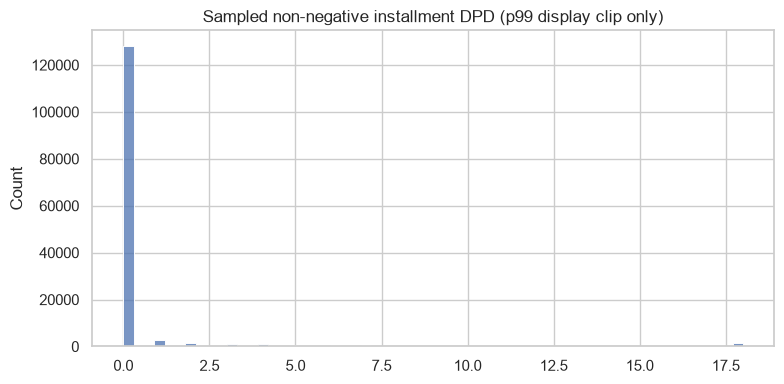

### FINDING
Among applicants with installment history, the observed rate is 6.80% for never-late histories and 9.41% when any late payment occurs. DPD is non-negative, so early payments cannot offset late ones.

### IMPLICATION
Keep a compact lifetime repayment family. Last-N windows, thresholds, latest states, and slopes are intentionally outside this portfolio version.

In [24]:
installment_state = {}
dpd_samples = []
for chunk in pd.read_csv(DATA_DIR / "installments_payments.csv", usecols=[
    ID_COL, "DAYS_INSTALMENT", "DAYS_ENTRY_PAYMENT", "AMT_INSTALMENT", "AMT_PAYMENT",
], chunksize=1_000_000):
    record_time_range("installments", "DAYS_INSTALMENT", chunk["DAYS_INSTALMENT"])
    record_time_range("installments", "DAYS_ENTRY_PAYMENT", chunk["DAYS_ENTRY_PAYMENT"])
    delay = chunk["DAYS_ENTRY_PAYMENT"] - chunk["DAYS_INSTALMENT"]
    dpd = delay.clip(lower=0); dbd = (-delay).clip(lower=0)
    ratio = safe_divide(chunk["AMT_PAYMENT"], chunk["AMT_INSTALMENT"], True)
    shortfall = (1 - ratio).clip(0, 1)
    observed_dpd = dpd.dropna()
    if len(observed_dpd):
        dpd_samples.append(observed_dpd.sample(min(10_000, len(observed_dpd)), random_state=RANDOM_STATE).astype("float32"))
    grouped = pd.DataFrame({
        ID_COL: chunk[ID_COL], "N": 1, "DPD_N": dpd.notna().astype("int8"), "DPD_SUM": dpd.fillna(0),
        "DPD_MAX": dpd, "DBD_SUM": dbd.fillna(0), "LATE": dpd.gt(0).astype("int8"),
        "RATIO_N": ratio.notna().astype("int8"), "RATIO_SUM": ratio.fillna(0),
        "SHORTFALL_SUM": shortfall.fillna(0), "UNDERPAID": shortfall.gt(0).astype("int8"),
    }).groupby(ID_COL)
    for metric in ["N", "DPD_N", "DPD_SUM", "DBD_SUM", "LATE", "RATIO_N", "RATIO_SUM", "SHORTFALL_SUM", "UNDERPAID"]:
        combine_state(installment_state, metric, grouped[metric].sum())
    combine_state(installment_state, "DPD_MAX", grouped["DPD_MAX"].max(), "max")
inst_raw = pd.DataFrame(installment_state)
inst_eda = pd.DataFrame(index=inst_raw.index)
inst_eda["INSTALLMENT_RECORD_COUNT"] = inst_raw["N"]
inst_eda["HAS_INSTALLMENT_HISTORY"] = 1
inst_eda["INSTALLMENT_MEAN_DPD"] = safe_divide(inst_raw["DPD_SUM"], inst_raw["DPD_N"])
inst_eda["INSTALLMENT_MAX_DPD"] = inst_raw["DPD_MAX"]
inst_eda["INSTALLMENT_MEAN_DBD"] = safe_divide(inst_raw["DBD_SUM"], inst_raw["DPD_N"])
inst_eda["INSTALLMENT_LATE_SHARE"] = safe_divide(inst_raw["LATE"], inst_raw["DPD_N"])
inst_eda["INSTALLMENT_MEAN_PAYMENT_RATIO"] = safe_divide(inst_raw["RATIO_SUM"], inst_raw["RATIO_N"])
inst_eda["INSTALLMENT_MEAN_SHORTFALL_RATIO"] = safe_divide(inst_raw["SHORTFALL_SUM"], inst_raw["RATIO_N"])
inst_eda["INSTALLMENT_UNDERPAID_SHARE"] = safe_divide(inst_raw["UNDERPAID"], inst_raw["RATIO_N"])
inst_eval = target_base.merge(inst_eda, left_on=ID_COL, right_index=True, how="left", validate="one_to_one")
inst_eval["HAS_INSTALLMENT_HISTORY"] = inst_eval["HAS_INSTALLMENT_HISTORY"].fillna(0).astype("int8")
display(history_presence_table(inst_eval, "HAS_INSTALLMENT_HISTORY").style.format({"default_rate": "{:.2%}"}))
installment_late_states = history_signal_table(inst_eval, "HAS_INSTALLMENT_HISTORY", inst_eval["INSTALLMENT_LATE_SHARE"].gt(0))
display(installment_late_states.style.format({"default_rate": "{:.2%}"}))
for column in ["INSTALLMENT_MEAN_DPD", "INSTALLMENT_LATE_SHARE", "INSTALLMENT_MEAN_PAYMENT_RATIO"]:
    display(Markdown(f"**{column}**"))
    display(quantile_default_table(inst_eval[inst_eval.HAS_INSTALLMENT_HISTORY.eq(1)], column, bins=5).style.format({"default_rate": "{:.2%}"}))
dpd_sample = pd.concat(dpd_samples, ignore_index=True)
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(dpd_sample.clip(upper=dpd_sample.quantile(.99)), bins=60, ax=ax)
ax.set_title("Sampled non-negative installment DPD (p99 display clip only)")
plt.tight_layout(); plt.show()
late_absent_rate = installment_late_states.loc["HISTORY_SIGNAL_ABSENT", "default_rate"]
late_present_rate = installment_late_states.loc["HISTORY_SIGNAL_PRESENT", "default_rate"]
show_finding(
    f"Among applicants with installment history, the observed rate is {late_absent_rate:.2%} for never-late histories and {late_present_rate:.2%} when any late payment occurs. DPD is non-negative, so early payments cannot offset late ones.",
    "Keep a compact lifetime repayment family. Last-N windows, thresholds, latest states, and slopes are intentionally outside this portfolio version.",
)
del installment_state, dpd_samples, dpd_sample

## 14. POS/CASH

### QUESTION
Does repeated delinquency, expressed as a count/share of months, retain more information than simply ever being delinquent?

### ACTION
Aggregate record count, DPD/DPD_DEF counts, shares, and maxima in chunks; compare history presence, any DPD, and DPD-share bins.

In [25]:
pos_state = {}
for chunk in pd.read_csv(DATA_DIR / "POS_CASH_balance.csv", usecols=[ID_COL, "MONTHS_BALANCE", "SK_DPD", "SK_DPD_DEF"], chunksize=1_000_000):
    record_time_range("POS_CASH", "MONTHS_BALANCE", chunk["MONTHS_BALANCE"])
    grouped = pd.DataFrame({
        ID_COL: chunk[ID_COL], "N": 1, "DPD_MONTHS": chunk["SK_DPD"].gt(0).astype("int8"),
        "DPD_MAX": chunk["SK_DPD"], "DEF_MONTHS": chunk["SK_DPD_DEF"].gt(0).astype("int8"), "DEF_MAX": chunk["SK_DPD_DEF"],
    }).groupby(ID_COL)
    for metric in ["N", "DPD_MONTHS", "DEF_MONTHS"]: combine_state(pos_state, metric, grouped[metric].sum())
    for metric in ["DPD_MAX", "DEF_MAX"]: combine_state(pos_state, metric, grouped[metric].max(), "max")
pos_raw = pd.DataFrame(pos_state)
pos_eda = pd.DataFrame(index=pos_raw.index)
pos_eda["POS_RECORD_COUNT"] = pos_raw["N"]; pos_eda["HAS_POS_HISTORY"] = 1
pos_eda["POS_DPD_MONTHS"] = pos_raw["DPD_MONTHS"]; pos_eda["POS_DPD_MAX"] = pos_raw["DPD_MAX"]
pos_eda["POS_DPD_SHARE"] = safe_divide(pos_raw["DPD_MONTHS"], pos_raw["N"])
pos_eda["POS_DPD_DEF_SHARE"] = safe_divide(pos_raw["DEF_MONTHS"], pos_raw["N"])
pos_eval = target_base.merge(pos_eda, left_on=ID_COL, right_index=True, how="left", validate="one_to_one")
pos_eval["HAS_POS_HISTORY"] = pos_eval["HAS_POS_HISTORY"].fillna(0).astype("int8")
display(history_presence_table(pos_eval, "HAS_POS_HISTORY").style.format({"default_rate": "{:.2%}"}))
pos_dpd_states = history_signal_table(pos_eval, "HAS_POS_HISTORY", pos_eval["POS_DPD_SHARE"].gt(0))
display(pos_dpd_states.style.format({"default_rate": "{:.2%}"}))
display(quantile_default_table(pos_eval[pos_eval.HAS_POS_HISTORY.eq(1)], "POS_DPD_SHARE", bins=5).style.format({"default_rate": "{:.2%}"}))
pos_present_rate = pos_dpd_states.loc["HISTORY_SIGNAL_PRESENT", "default_rate"]
show_finding(
    f"Applicants with POS history and any observed DPD have a {pos_present_rate:.2%} default rate; the share table shows the observed pattern for repeated delinquency.",
    "Keep count/share/max and simple flags only. Do not add recent windows or product interactions.",
)
del pos_state

,applicants,default_rate
_state,,
HAS_HISTORY,289444,8.16%
NO_HISTORY,18067,6.66%


,applicants,default_rate
_state,,
HISTORY_SIGNAL_ABSENT,234761,7.72%
HISTORY_SIGNAL_PRESENT,54683,10.06%
NO_HISTORY,18067,6.66%


,bin,applicants,defaults,default_rate,feature_median
0,"(-0.001, 1.0]",289444,23621,8.16%,0.000000


### FINDING
Applicants with POS history and any observed DPD have a 10.06% default rate; the share table shows the observed pattern for repeated delinquency.

### IMPLICATION
Keep count/share/max and simple flags only. Do not add recent windows or product interactions.

## 15. Credit cards

### QUESTION
Does utilization add a clearer relative burden view than raw balance, and how do over-limit frequency and delinquency behave?

### ACTION
Calculate safe row utilization only for positive limits, then aggregate balance mean, utilization mean/max, over-limit count/share, and DPD count/share/max.

In [26]:
card_state = {}
for chunk in pd.read_csv(DATA_DIR / "credit_card_balance.csv", usecols=[ID_COL, "MONTHS_BALANCE", "AMT_BALANCE", "AMT_CREDIT_LIMIT_ACTUAL", "SK_DPD", "SK_DPD_DEF"], chunksize=750_000):
    record_time_range("credit_card", "MONTHS_BALANCE", chunk["MONTHS_BALANCE"])
    util = safe_divide(chunk["AMT_BALANCE"].clip(lower=0), chunk["AMT_CREDIT_LIMIT_ACTUAL"], True)
    grouped = pd.DataFrame({
        ID_COL: chunk[ID_COL], "N": 1, "BAL_N": chunk["AMT_BALANCE"].notna().astype("int8"), "BAL_SUM": chunk["AMT_BALANCE"].fillna(0),
        "UTIL_N": util.notna().astype("int8"), "UTIL_SUM": util.fillna(0), "UTIL_MAX": util,
        "OVER": util.gt(1).astype("int8"), "DPD_MONTHS": chunk["SK_DPD"].gt(0).astype("int8"),
        "DPD_MAX": chunk["SK_DPD"], "DPD_DEF_MAX": chunk["SK_DPD_DEF"],
    }).groupby(ID_COL)
    for metric in ["N", "BAL_N", "BAL_SUM", "UTIL_N", "UTIL_SUM", "OVER", "DPD_MONTHS"]: combine_state(card_state, metric, grouped[metric].sum())
    for metric in ["UTIL_MAX", "DPD_MAX", "DPD_DEF_MAX"]: combine_state(card_state, metric, grouped[metric].max(), "max")
card_raw = pd.DataFrame(card_state)
card_eda = pd.DataFrame(index=card_raw.index)
card_eda["CARD_RECORD_COUNT"] = card_raw["N"]; card_eda["HAS_CARD_HISTORY"] = 1
card_eda["CARD_BALANCE_MEAN"] = safe_divide(card_raw["BAL_SUM"], card_raw["BAL_N"])
card_eda["CARD_UTIL_MEAN"] = safe_divide(card_raw["UTIL_SUM"], card_raw["UTIL_N"])
card_eda["CARD_UTIL_MAX"] = card_raw["UTIL_MAX"]
card_eda["CARD_OVER_LIMIT_SHARE"] = safe_divide(card_raw["OVER"], card_raw["UTIL_N"])
card_eda["CARD_DPD_MAX"] = card_raw["DPD_MAX"]
card_eda["CARD_DPD_DEF_MAX"] = card_raw["DPD_DEF_MAX"]
card_eda["CARD_DPD_SHARE"] = safe_divide(card_raw["DPD_MONTHS"], card_raw["N"])
card_eval = target_base.merge(card_eda, left_on=ID_COL, right_index=True, how="left", validate="one_to_one")
card_eval["HAS_CARD_HISTORY"] = card_eval["HAS_CARD_HISTORY"].fillna(0).astype("int8")
display(history_presence_table(card_eval, "HAS_CARD_HISTORY").style.format({"default_rate": "{:.2%}"}))
card_dpd_states = history_signal_table(card_eval, "HAS_CARD_HISTORY", card_eval["CARD_DPD_SHARE"].gt(0))
display(card_dpd_states.style.format({"default_rate": "{:.2%}"}))
for column in ["CARD_BALANCE_MEAN", "CARD_UTIL_MEAN", "CARD_OVER_LIMIT_SHARE", "CARD_DPD_SHARE"]:
    display(Markdown(f"**{column}**"))
    display(quantile_default_table(card_eval[card_eval.HAS_CARD_HISTORY.eq(1)], column, bins=5).style.format({"default_rate": "{:.2%}"}))
card_dpd_present_rate = card_dpd_states.loc["HISTORY_SIGNAL_PRESENT", "default_rate"]
show_finding(
    f"Among applicants with card history and observed DPD, the default rate is {card_dpd_present_rate:.2%}. The displayed balance and utilization bins allow their target-rate shapes to be compared directly.",
    "Retain both raw balance scale and relative utilization, plus compact over-limit and DPD summaries. Recent/latest/trend families are rejected here.",
)
del card_state

,applicants,default_rate
_state,,
HAS_HISTORY,86905,8.67%
NO_HISTORY,220606,7.84%


,applicants,default_rate
_state,,
HISTORY_SIGNAL_ABSENT,69023,8.79%
HISTORY_SIGNAL_PRESENT,17882,8.22%
NO_HISTORY,220606,7.84%


**CARD_BALANCE_MEAN**

,bin,applicants,defaults,default_rate,feature_median
0,"(-2930.2340000000004, 0.0]",27333,1514,5.54%,0.000000
1,"(0.0, 9436.796]",7429,469,6.31%,3787.398791
2,"(9436.796, 49230.344]",17381,1418,8.16%,26793.606316
3,"(49230.344, 122497.188]",17381,1858,10.69%,79982.358750
4,"(122497.188, 928686.324]",17381,2275,13.09%,201679.358182


**CARD_UTIL_MEAN**

...

**CARD_OVER_LIMIT_SHARE**

,bin,applicants,defaults,default_rate,feature_median
0,"(-0.001, 0.0294]",51649,3180,6.16%,0.000000
1,"(0.0294, 0.181]",17183,1477,8.60%,0.086957
2,"(0.181, 1.0]",17204,2774,16.12%,0.361111


**CARD_DPD_SHARE**

,bin,applicants,defaults,default_rate,feature_median
0,"(-0.001, 0.0104]",69946,6111,8.74%,0.000000
1,"(0.0104, 0.989]",16959,1423,8.39%,0.052083


### FINDING
Among applicants with card history and observed DPD, the default rate is 8.22%. The displayed balance and utilization bins allow their target-rate shapes to be compared directly.

### IMPLICATION
Retain both raw balance scale and relative utilization, plus compact over-limit and DPD summaries. Recent/latest/trend families are rejected here.

## 16. Can simple summaries preserve variable-length histories?

### QUESTION
Each applicant has a different number of historical rows. Can selected count/mean/min/max/sum statistics preserve useful information without creating hundreds of features?

### ACTION
Review the specific raw variables and statistics tested above. IDs are used only as keys and are never aggregated as measurements.

In [27]:
aggregation_manifest = pd.DataFrame([
    ["bureau", "AMT_CREDIT_SUM", "sum", "lifetime credit exposure"],
    ["bureau", "AMT_CREDIT_SUM_DEBT", "sum", "outstanding debt"],
    ["bureau", "DAYS_CREDIT", "mean, max", "average history age and most recent loan"],
    ["previous_application", "AMT_APPLICATION", "mean, max", "typical and largest request"],
    ["previous_application", "AMT_CREDIT", "mean, max", "typical and largest granted amount"],
    ["previous_application", "DAYS_DECISION", "mean, max", "history age and recency"],
    ["installments", "DPD", "mean, max", "typical and worst lateness"],
    ["installments", "payment ratio", "mean", "payment completeness"],
    ["credit_card", "AMT_BALANCE", "mean", "typical balance"],
    ["credit_card", "utilization", "mean, max", "typical and peak relative balance"],
    ["credit_card", "SK_DPD", "count/share, max", "frequency and severity"],
], columns=["Source", "Raw variable", "Statistics", "Reason"])
display(aggregation_manifest)
show_finding(
    "The preceding applicant-level bin tables show that selected summaries retain differences in history depth, typical behavior, and extremes while preserving one row per applicant.",
    "Use an explicit aggregation manifest rather than automatically aggregating every numeric column.",
)

,Source,Raw variable,Statistics,Reason
0,bureau,AMT_CREDIT_SUM,sum,lifetime credit exposure
1,bureau,AMT_CREDIT_SUM_DEBT,sum,outstanding debt
2,bureau,DAYS_CREDIT,"mean, max",average history age and most recent loan
3,previous_application,AMT_APPLICATION,"mean, max",typical and largest request
4,previous_application,AMT_CREDIT,"mean, max",typical and largest granted amount
5,previous_application,DAYS_DECISION,"mean, max",history age and recency
6,installments,DPD,"mean, max",typical and worst lateness
7,installments,payment ratio,mean,payment completeness
8,credit_card,AMT_BALANCE,mean,typical balance
9,credit_card,utilization,"mean, max",typical and peak relative balance


### FINDING
The preceding applicant-level bin tables show that selected summaries retain differences in history depth, typical behavior, and extremes while preserving one row per applicant.

### IMPLICATION
Use an explicit aggregation manifest rather than automatically aggregating every numeric column.

## 17. Small cross-table burden ratios

### QUESTION
If current affordability ratios are interpretable, does historical bureau exposure relative to current income provide a similarly useful view?

### ACTION
Join only the temporary bureau totals to application income and inspect debt/income and credit/income bins.

In [28]:
cross_eval = target_base.merge(bureau_eda[["BUREAU_DEBT_SUM", "BUREAU_CREDIT_SUM"]], left_on=ID_COL, right_index=True, how="left", validate="one_to_one")
cross_eval["BUREAU_DEBT_INCOME_RATIO"] = safe_divide(cross_eval["BUREAU_DEBT_SUM"], app_train["AMT_INCOME_TOTAL"])
cross_eval["BUREAU_CREDIT_INCOME_RATIO"] = safe_divide(cross_eval["BUREAU_CREDIT_SUM"], app_train["AMT_INCOME_TOTAL"])
for column in ["BUREAU_DEBT_INCOME_RATIO", "BUREAU_CREDIT_INCOME_RATIO"]:
    display(Markdown(f"**{column}**"))
    display(quantile_default_table(cross_eval, column, bins=5).style.format({"default_rate": "{:.2%}"}))
show_finding(
    "The displayed bins provide the actual applicant counts and target rates for historical debt and credit normalized by current income.",
    "Add these two ratios only; a broad cross-table ratio matrix would be harder to explain and validate.",
)

**BUREAU_DEBT_INCOME_RATIO**

,bin,applicants,defaults,default_rate,feature_median
0,"(-15.516, 0.0]",70985,3947,5.56%,0.000000
1,"(0.0, 0.608]",31468,2428,7.72%,0.284902
2,"(0.608, 2.199]",51226,4135,8.07%,1.283553
3,"(2.199, 5.544]",51226,4569,8.92%,3.517112
4,"(5.544, 1651.844]",51226,4795,9.36%,9.372669


**BUREAU_CREDIT_INCOME_RATIO**

,bin,applicants,defaults,default_rate,feature_median
0,"(-0.001, 1.936]",52698,4514,8.57%,0.907221
1,"(1.936, 4.786]",52698,4049,7.68%,3.200000
2,"(4.786, 9.065]",52699,4032,7.65%,6.668193
3,"(9.065, 16.908]",52697,3950,7.50%,12.200000
4,"(16.908, 8378.254]",52698,3823,7.25%,25.769079


### FINDING
The displayed bins provide the actual applicant counts and target rates for historical debt and credit normalized by current income.

### IMPLICATION
Add these two ratios only; a broad cross-table ratio matrix would be harder to explain and validate.

## 18. Temporal audit results

In [29]:
temporal_audit = pd.DataFrame(TIME_RANGES.values()).sort_values(["table", "column"])
display(temporal_audit)
assert temporal_audit["positive"].eq(0).all()
show_finding(
    "All time fields I plan to use are non-positive in the observed raw data, including DAYS_CREDIT, DAYS_DECISION, DAYS_INSTALMENT, DAYS_ENTRY_PAYMENT, and both MONTHS_BALANCE fields.",
    "The feature pipeline can use their mean/max summaries as historical depth or recency without introducing post-application observations.",
)

,table,column,min,max,missing,positive
5,POS_CASH,MONTHS_BALANCE,-96.000,-1.000,0,0
0,bureau,DAYS_CREDIT,"-2,922.000",0.000,0,0
1,bureau_balance,MONTHS_BALANCE,-96.000,0.000,0,0
6,credit_card,MONTHS_BALANCE,-96.000,-1.000,0,0
4,installments,DAYS_ENTRY_PAYMENT,"-4,921.000",-1.000,2905,0
3,installments,DAYS_INSTALMENT,"-2,922.000",-1.000,0,0
2,previous_application,DAYS_DECISION,"-2,922.000",-1.000,0,0


### FINDING
All time fields used in the refined features are non-positive in the observed raw data, including DAYS_CREDIT, DAYS_DECISION, DAYS_INSTALMENT, DAYS_ENTRY_PAYMENT, and both MONTHS_BALANCE fields.

### IMPLICATION
The refined pipeline can use their mean/max summaries as historical depth or recency without introducing post-application observations.

## 19. EDA → feature traceability

In [30]:
TRACEABILITY = pd.DataFrame([
    ["Do affordability and score variables vary across risk groups?", "Application decile tables report counts and default rates for EXT_SOURCE_MEAN, three safe ratios, and age.", "EXT_SOURCE_MEAN; ANNUITY_CREDIT_RATIO; CREDIT_GOODS_RATIO; INCOME_CREDIT_RATIO; AGE_YEARS", "application_train.csv"],
    ["Does active bureau composition matter?", f"Among bureau-history applicants: {active_absent_rate:.2%} without active credit versus {active_present_rate:.2%} with it.", "BUREAU_ACTIVE_COUNT; BUREAU_ACTIVE_SHARE; BUREAU_CLOSED_COUNT; BUREAU_CLOSED_SHARE", "bureau.csv"],
    ["How large is bureau burden?", "Debt/credit bins above report applicant counts and default rates.", "BUREAU_CREDIT_SUM; BUREAU_DEBT_SUM; BUREAU_OVERDUE_SUM; BUREAU_DEBT_CREDIT_RATIO", "bureau.csv"],
    ["Is microloan count more informative than presence alone?", "Microloan-count bins are displayed among applicants with bureau history.", "HAS_MICROLOAN; BUREAU_MICROLOAN_COUNT", "bureau.csv"],
    ["Has linked bureau monthly history ever been delinquent?", f"Among bureau-balance-history applicants: {bb_absent_rate:.2%} without versus {bb_present_rate:.2%} with numeric-status delinquency.", "BUREAU_BAL_EVER_DELINQUENT; BUREAU_BAL_DELINQUENT_SHARE; BUREAU_BAL_WORST_STATUS", "bureau_balance.csv"],
    ["Does repeated refusal differ from binary presence?", f"Among previous-history applicants: {refused_absent_rate:.2%} without refusal versus {refused_present_rate:.2%} with one; refused-share bins retain frequency.", "HAS_REFUSED_PRIOR; PREV_REFUSED_COUNT; PREV_REFUSED_SHARE", "previous_application.csv"],
    ["How recent and how large were prior applications?", "Decision-day and application/credit-ratio bins are displayed above.", "PREV_APPLICATION_AMT_MEAN/MAX; PREV_CREDIT_AMT_MEAN/MAX; PREV_APPLICATION_CREDIT_RATIO_MEAN; PREV_DAYS_DECISION_MEAN/MAX", "previous_application.csv"],
    ["How often and how severely was payment late?", f"Among installment-history applicants: {late_absent_rate:.2%} never late versus {late_present_rate:.2%} ever late; DPD bins show severity.", "INSTALLMENT_MEAN_DPD; INSTALLMENT_MAX_DPD; INSTALLMENT_LATE_SHARE; ANY_LATE_INSTALLMENT", "installments_payments.csv"],
    ["Does repeated POS delinquency add context?", "POS DPD-share bins and the any-DPD three-state comparison are displayed above.", "POS_DPD_MONTHS; POS_DPD_MAX; POS_DPD_SHARE; ANY_POS_DPD", "POS_CASH_balance.csv"],
    ["Does utilization complement raw card balance?", "Balance, utilization, over-limit, and DPD-share bins are displayed on card-history applicants only; DPD and DPD_DEF maxima preserve severity.", "CARD_BALANCE_MEAN; CARD_UTIL_MEAN/MAX; CARD_OVER_LIMIT_SHARE; CARD_DPD_MAX; CARD_DPD_DEF_MAX; CARD_DPD_SHARE", "credit_card_balance.csv"],
    ["Does historical exposure relative to income matter?", "Debt/income and credit/income bins report counts and observed target rates.", "BUREAU_DEBT_INCOME_RATIO; BUREAU_CREDIT_INCOME_RATIO", "bureau.csv + application_train.csv"],
], columns=["Question", "Evidence", "Feature idea", "Source"])
display(TRACEABILITY)

,Question,Evidence,Feature idea,Source
0,Do affordability and score variables vary acro...,Application decile tables report counts and de...,EXT_SOURCE_MEAN; ANNUITY_CREDIT_RATIO; CREDIT_...,application_train.csv
1,Does active bureau composition matter?,Among bureau-history applicants: 5.66% without...,BUREAU_ACTIVE_COUNT; BUREAU_ACTIVE_SHARE; BURE...,bureau.csv
2,How large is bureau burden?,Debt/credit bins above report applicant counts...,BUREAU_CREDIT_SUM; BUREAU_DEBT_SUM; BUREAU_OVE...,bureau.csv
3,Is microloan count more informative than prese...,Microloan-count bins are displayed among appli...,HAS_MICROLOAN; BUREAU_MICROLOAN_COUNT,bureau.csv
4,Has linked bureau monthly history ever been de...,Among bureau-balance-history applicants: 7.22%...,BUREAU_BAL_EVER_DELINQUENT; BUREAU_BAL_DELINQU...,bureau_balance.csv
5,Does repeated refusal differ from binary prese...,Among previous-history applicants: 7.07% witho...,HAS_REFUSED_PRIOR; PREV_REFUSED_COUNT; PREV_RE...,previous_application.csv
6,How recent and how large were prior applications?,Decision-day and application/credit-ratio bins...,PREV_APPLICATION_AMT_MEAN/MAX; PREV_CREDIT_AMT...,previous_application.csv
7,How often and how severely was payment late?,Among installment-history applicants: 6.80% ne...,INSTALLMENT_MEAN_DPD; INSTALLMENT_MAX_DPD; INS...,installments_payments.csv
8,Does repeated POS delinquency add context?,POS DPD-share bins and the any-DPD three-state...,POS_DPD_MONTHS; POS_DPD_MAX; POS_DPD_SHARE; AN...,POS_CASH_balance.csv
9,Does utilization complement raw card balance?,"Balance, utilization, over-limit, and DPD-shar...",CARD_BALANCE_MEAN; CARD_UTIL_MEAN/MAX; CARD_OV...,credit_card_balance.csv


## EDA summary

Questions covered the application record, target imbalance, dtypes/cardinality, missingness, anomalies, application distributions, variable-length history depth, status shares, amount burdens, delinquency, repayment completeness, utilization, and a small number of cross-table affordability ratios.

The executed outputs—not external Kaggle feature lists—motivate the 81-feature implementation. Rejected ideas include last-N event windows, broad month-window families, trends/slopes, latest-state expansion, rare category interactions, exhaustive one-hot aggregation, and arbitrary ratio matrices. Quantile bins are diagnostic evidence only and are not saved as features. No engineered feature is claimed to improve prediction until the unchanged fixed cross-validation procedure tests it.